In [ ]:
# Install any missing packages
!pip install pandas scikit-learn matplotlib seaborn graphviz xgboost optuna shap mlxtend

import pandas as pd
import numpy as np

# Modeling
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import xgboost as xgb
import optuna
import shap

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Misc
import ast
import re
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

print("All dependencies loaded successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 31.2 MB/s eta 0:00:00
All dependencies loaded successfully.


Introduction

- Poker Basics
- Streets, actions, antes
- GTO

Motivation

- Increase popularity of non-professionals taking a shot at the main event
- Combines skill / luck -> is this a gambling epidemic?
- Want to examine the "levels" of players and learnability of the game

Using Colab cache for faster access to the 'wsop-main-event-results-1971-2024' dataset.
Path to dataset files: /kaggle/input/wsop-main-event-results-1971-2024


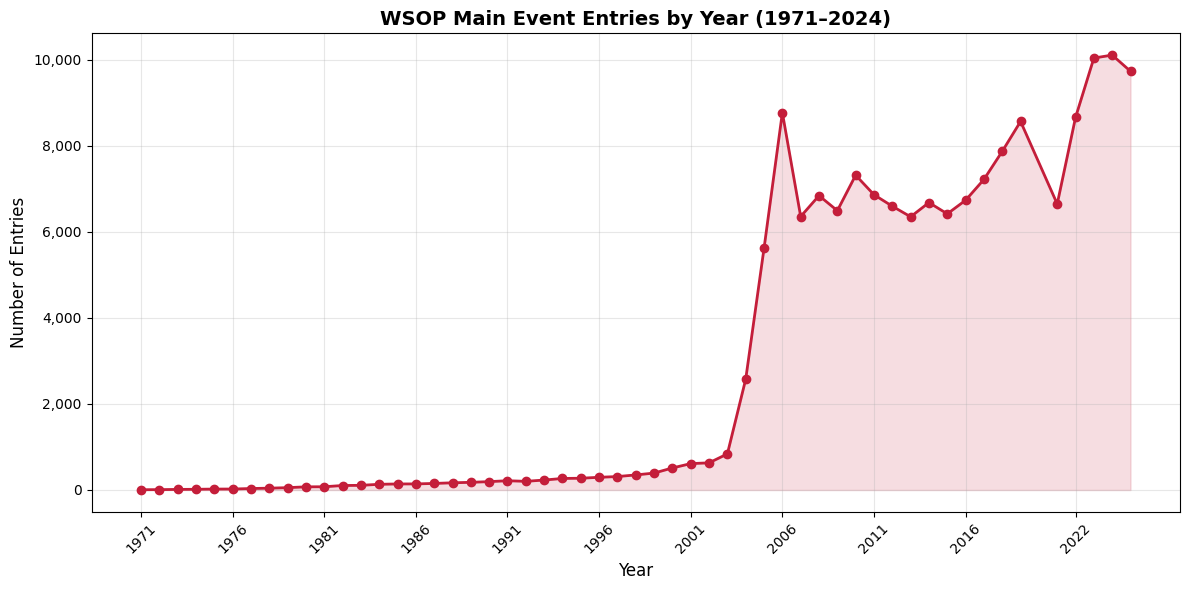

In [ ]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import os

# Download dataset
path = kagglehub.dataset_download("cviaxmiwnptr/wsop-main-event-results-1971-2024")
print("Path to dataset files:", path)

# Find and load the CSV
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, csv_file))

# Get one entries value per year (entries is the same for all rows in a given year)
entries_by_year = df.groupby('year')['entries'].first().reset_index()

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(entries_by_year['year'], entries_by_year['entries'],
        marker='o', linewidth=2, color='#c41e3a')
ax.fill_between(entries_by_year['year'], entries_by_year['entries'],
                alpha=0.15, color='#c41e3a')

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Entries', fontsize=12)
ax.set_title('WSOP Main Event Entries by Year (1971–2024)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

# Show every 5th year on x-axis to avoid clutter
years = entries_by_year['year'].values
ax.set_xticks(years[::5])
plt.xticks(rotation=45)

# Format y-axis with commas
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('wsop_entries.png', dpi=150)
plt.show()

Data Loading / Cleaning

In [ ]:
# Loading

from google.colab import files
uploaded = files.upload()

import pandas as pd

df = pd.read_csv("postflop_500k_train_set_game_scenario_information.csv")

df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 13 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   Unnamed: 0          500000 non-null  int64 
 1   preflop_action      500000 non-null  object
 2   board_flop          500000 non-null  object
 3   board_turn          500000 non-null  object
 4   board_river         500000 non-null  object
 5   aggressor_position  500000 non-null  object
 6   postflop_action     500000 non-null  object
 7   evaluation_at       500000 non-null  object
 8   available_moves     500000 non-null  object
 9   pot_size            500000 non-null  int64 
 10  hero_position       500000 non-null  object
 11  holding             500000 non-null  object
 12  correct_decision    500000 non-null  object
dtypes: int64(2), object(11)
memory usage: 49.6+ MB


In [ ]:
# Basic Cleaning
df = df.rename(columns={"Unnamed: 0": "Index"})

# Strip whitespace from column names
df.columns = df.columns.str.strip()

# Convert pot size to numeric (just in case)
df["pot_size"] = pd.to_numeric(df["pot_size"], errors="coerce")

# Make sure categorical columns are strings
cat_cols = [
    "preflop_action", "board_flop", "board_turn", "board_river",
    "aggressor_position", "postflop_action", "evaluation_at",
    "hero_position", "holding", "correct_decision"
]

for col in cat_cols:
    df[col] = df[col].astype(str)

df.head()

,Index,preflop_action,board_flop,board_turn,board_river,aggressor_position,postflop_action,evaluation_at,available_moves,pot_size,hero_position,holding,correct_decision
0,0,HJ/2.0bb/BB/call,JcJh4s,4d,As,OOP,OOP_CHECK/IP_BET_1/OOP_CALL/dealcards/4d/OOP_C...,River,"['Check', 'Bet 17']",21,IP,AhKd,Check
1,1,SB/3.0bb/BB/call,6s8d7c,9s,3c,OOP,OOP_CHECK/IP_CHECK/dealcards/9s/OOP_BET_5/IP_R...,Turn,"['Fold', 'Call', 'Raise 41']",27,OOP,Tc9c,Call
2,2,UTG/2.0bb/CO/6.5bb/UTG/call,JcJh4s,4d,As,IP,OOP_CHECK/IP_BET_7/OOP_RAISE_16/IP_CALL/dealca...,Turn,"['Fold', 'Call']",151,IP,QsQh,Call
3,3,UTG/2.0bb/BTN/call,Th3s2d,5d,3c,OOP,OOP_CHECK/IP_CHECK/dealcards/5d/OOP_BET_6/IP_C...,River,"['Check', 'Bet 13']",17,IP,JcTc,Check
4,4,CO/2.3bb/BB/call,Ks7h2d,Jc,Qc,OOP,OOP_CHECK/IP_CHECK/dealcards/Jc/OOP_CHECK/IP_B...,River,"['Check', 'Bet 29']",39,IP,Ac5c,Bet 29


In [ ]:
def simplify_action(action):
    action = action.lower()

    if "bet" in action or "raise" in action:
        return "Bet/Raise"
    elif "check" in action:
        return "Check"
    elif "call" in action:
        return "Call"
    elif "fold" in action:
        return "Fold"
    else:
        return "Other"

def simplify_available_moves(moves):
    simplified = set()
    moves = moves.split(",")
    for move in moves:
        move = move.lower()
        if "bet" in move or "raise" in move:
            simplified.add("Bet/Raise")
        elif "check" in move:
            simplified.add("Check")
        elif "call" in move:
            simplified.add("Call")
        elif "fold" in move:
            simplified.add("Fold")
        else:
            simplified.add("Other")
    return sorted(simplified)

df["available_moves_simplified"] = df["available_moves"].apply(simplify_available_moves)
df["decision_category"] = df["correct_decision"].apply(simplify_action)
df_simplified = df.drop(columns=['correct_decision','available_moves', 'Index'])

df_simplified.head()

,preflop_action,board_flop,board_turn,board_river,aggressor_position,postflop_action,evaluation_at,pot_size,hero_position,holding,available_moves_simplified,decision_category
0,HJ/2.0bb/BB/call,JcJh4s,4d,As,OOP,OOP_CHECK/IP_BET_1/OOP_CALL/dealcards/4d/OOP_C...,River,21,IP,AhKd,"[Bet/Raise, Check]",Check
1,SB/3.0bb/BB/call,6s8d7c,9s,3c,OOP,OOP_CHECK/IP_CHECK/dealcards/9s/OOP_BET_5/IP_R...,Turn,27,OOP,Tc9c,"[Bet/Raise, Call, Fold]",Call
2,UTG/2.0bb/CO/6.5bb/UTG/call,JcJh4s,4d,As,IP,OOP_CHECK/IP_BET_7/OOP_RAISE_16/IP_CALL/dealca...,Turn,151,IP,QsQh,"[Call, Fold]",Call
3,UTG/2.0bb/BTN/call,Th3s2d,5d,3c,OOP,OOP_CHECK/IP_CHECK/dealcards/5d/OOP_BET_6/IP_C...,River,17,IP,JcTc,"[Bet/Raise, Check]",Check
4,CO/2.3bb/BB/call,Ks7h2d,Jc,Qc,OOP,OOP_CHECK/IP_CHECK/dealcards/Jc/OOP_CHECK/IP_B...,River,39,IP,Ac5c,"[Bet/Raise, Check]",Bet/Raise


Baseline

- Based on PokerBench research paper:
- Pre-trained ChatGPT-4 achieved action accuracy of 62.69%
- Fine-tuned LLAMA-3 achieved action accuracy of 79.07%

In [ ]:
import numpy as np

# Expected accuracy (analytical — exact, no randomness)
expected_accuracy = (1 / df['available_moves_simplified'].apply(len)).mean()
print(f"Expected random-baseline accuracy: {expected_accuracy:.4f} ({expected_accuracy*100:.2f}%)")

# Distribution of available-move counts (helps interpret the baseline)
print("\nAvailable-move counts:")
print(df['available_moves_simplified'].apply(len).value_counts().sort_index())

Expected random-baseline accuracy: 0.4097 (40.97%)

Available-move counts:
available_moves_simplified
2    229006
3    270994
Name: count, dtype: int64


In [ ]:
rng = np.random.default_rng(42)

def random_guess(moves):
    return rng.choice(moves)

# Single simulated run
df['random_guess'] = df['available_moves_simplified'].apply(random_guess)
simulated_accuracy = (df['random_guess'] == df['decision_category']).mean()
print(f"Simulated accuracy (1 run): {simulated_accuracy:.4f}")

# Average over many runs for a tighter estimate
n_runs = 10
accuracies = []
for _ in range(n_runs):
    guesses = df['available_moves_simplified'].apply(random_guess)
    accuracies.append((guesses == df['decision_category']).mean())
print(f"Simulated accuracy ({n_runs} runs): {np.mean(accuracies):.4f} ± {np.std(accuracies):.4f}")

df = df.drop(columns=['random_guess'])

Simulated accuracy (1 run): 0.4097
Simulated accuracy (10 runs): 0.4095 ± 0.0005


Basic Players (Own Hand)

In [ ]:
df_own_hand = df_simplified.drop(columns=['preflop_action','board_flop', 'board_turn', 'board_river', 'aggressor_position', 'postflop_action', 'evaluation_at', 'pot_size', 'hero_position'])
df_own_hand.head()

,holding,available_moves_simplified,decision_category
0,AhKd,"[Bet/Raise, Check]",Check
1,Tc9c,"[Bet/Raise, Call, Fold]",Call
2,QsQh,"[Call, Fold]",Call
3,JcTc,"[Bet/Raise, Check]",Check
4,Ac5c,"[Bet/Raise, Check]",Bet/Raise


In [ ]:
import pandas as pd

# Rank mapping (Ace high = 14)
RANK_VALUES = {
    '2': 2, '3': 3, '4': 4, '5': 5, '6': 6, '7': 7, '8': 8,
    '9': 9, 'T': 10, 'J': 11, 'Q': 12, 'K': 13, 'A': 14
}

def parse_holding(holding):
    """Extract the two rank characters from a 4-char holding like 'AhKd'."""
    return RANK_VALUES[holding[0]], RANK_VALUES[holding[2]]

# Holding features
ranks = df_own_hand['holding'].apply(parse_holding)
df_own_hand['rank1'] = ranks.apply(lambda r: r[0])
df_own_hand['rank2'] = ranks.apply(lambda r: r[1])
df_own_hand['is_pair'] = (df_own_hand['rank1'] == df_own_hand['rank2']).astype(int)
df_own_hand['rank_sum'] = df_own_hand['rank1'] + df_own_hand['rank2']
df_own_hand['rank_max'] = df_own_hand[['rank1', 'rank2']].max(axis=1)

# Available-moves features: consolidated
# facing_bet = 1 if hero faces a bet (can call/fold), 0 if not (can check)
df_own_hand['facing_bet'] = df_own_hand['available_moves_simplified'].apply(
    lambda m: int('Call' in m)
)
df_own_hand['can_bet_raise'] = df_own_hand['available_moves_simplified'].apply(
    lambda m: int('Bet/Raise' in m)
)

# Drop the now-redundant columns before training
df_own_hand = df_own_hand.drop(columns=['holding', 'available_moves_simplified', 'rank1', 'rank2'])

df_own_hand.head()

,decision_category,is_pair,rank_sum,rank_max,facing_bet,can_bet_raise
0,Check,0,27,14,0,1
1,Call,0,19,10,1,1
2,Call,1,24,12,1,0
3,Check,0,21,11,0,1
4,Bet/Raise,0,19,14,0,1


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Define features and target
feature_cols = ['is_pair', 'rank_sum', 'rank_max',
                'can_bet_raise', 'facing_bet']
X = df_own_hand[feature_cols]
y = df_own_hand['decision_category']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train
clf = DecisionTreeClassifier(max_depth=5, random_state=42)
clf.fit(X_train, y_train)

# Evaluate
train_acc = accuracy_score(y_train, clf.predict(X_train))
test_acc = accuracy_score(y_test, clf.predict(X_test))

print(f"Training accuracy: {train_acc:.4f} ({train_acc*100:.2f}%)")
print(f"Test accuracy:     {test_acc:.4f} ({test_acc*100:.2f}%)")

Training accuracy: 0.5469 (54.69%)
Test accuracy:     0.5463 (54.63%)


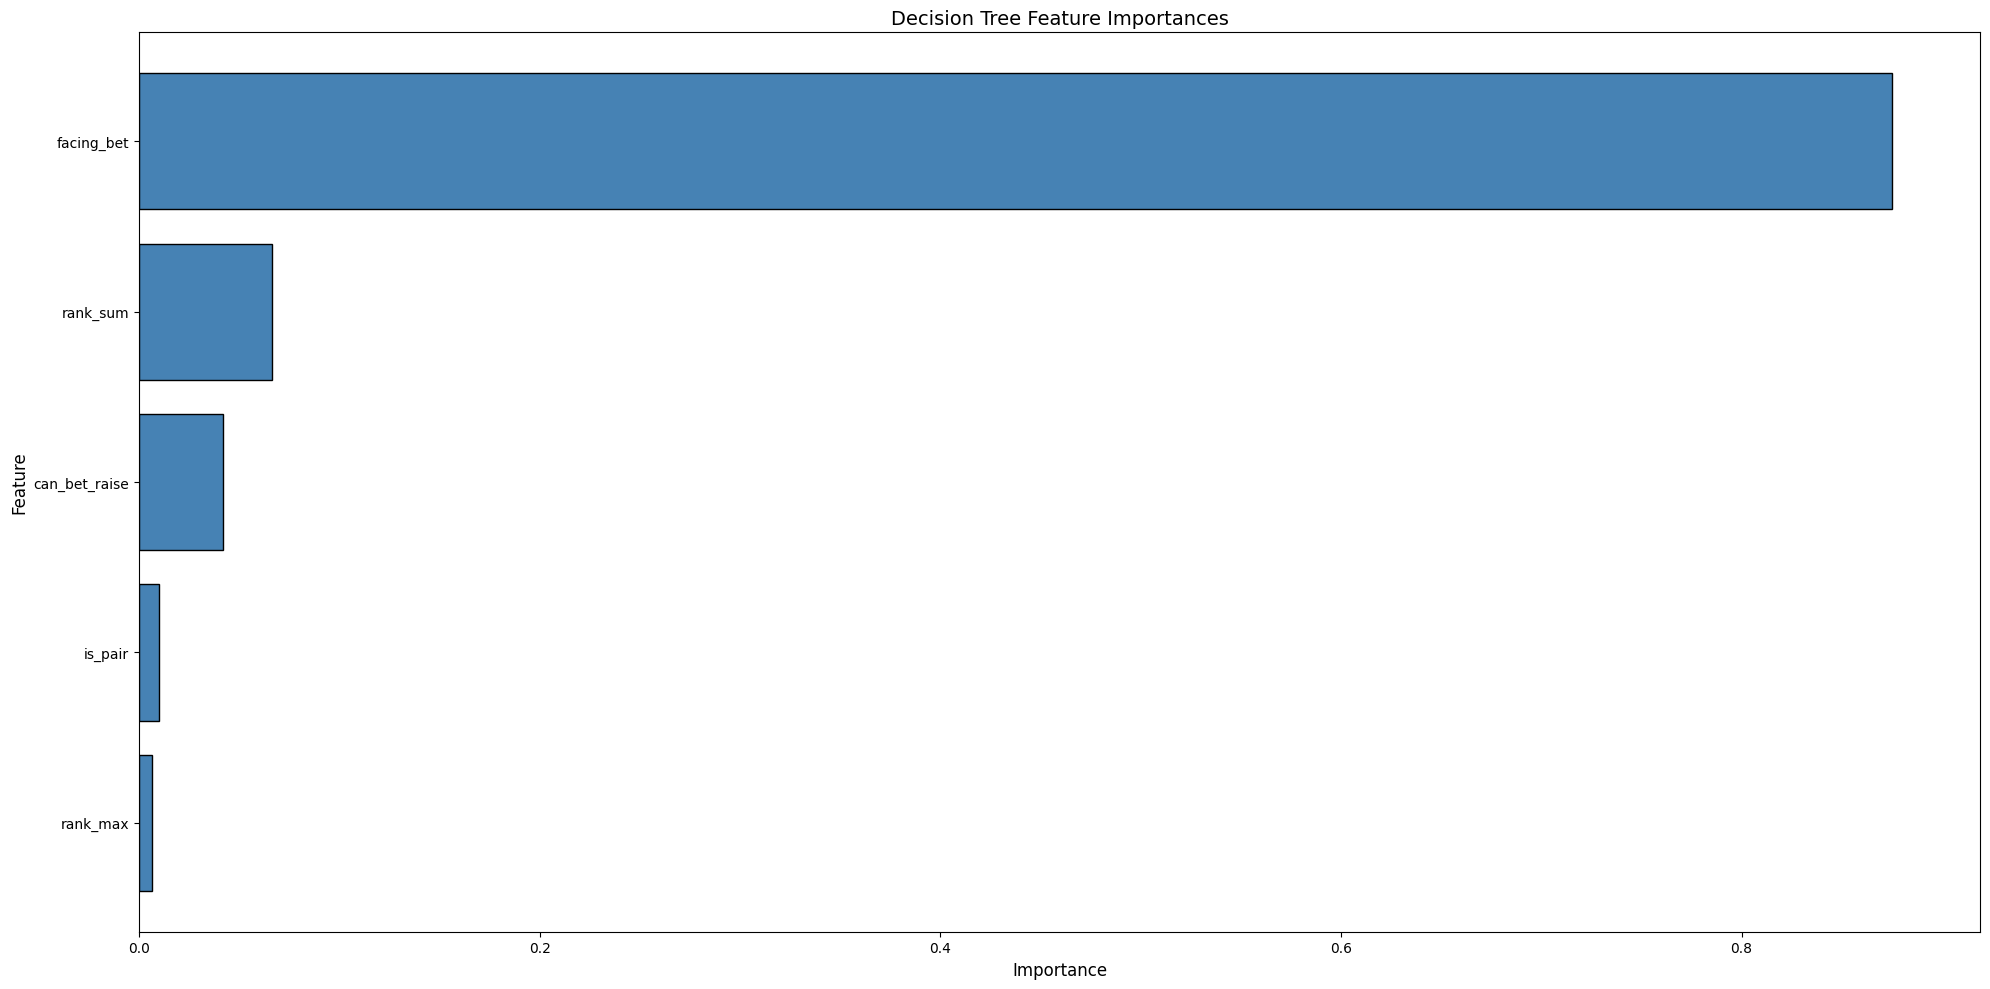

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Sort features by importance
indices = np.argsort(clf.feature_importances_)[::-1]
sorted_features = [feature_cols[i] for i in indices]
sorted_importances = clf.feature_importances_[indices]

plt.figure(figsize=(20, 10))
plt.barh(sorted_features[::-1], sorted_importances[::-1], color='steelblue', edgecolor='black')
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Decision Tree Feature Importances', fontsize=14)
plt.tight_layout()
plt.show()

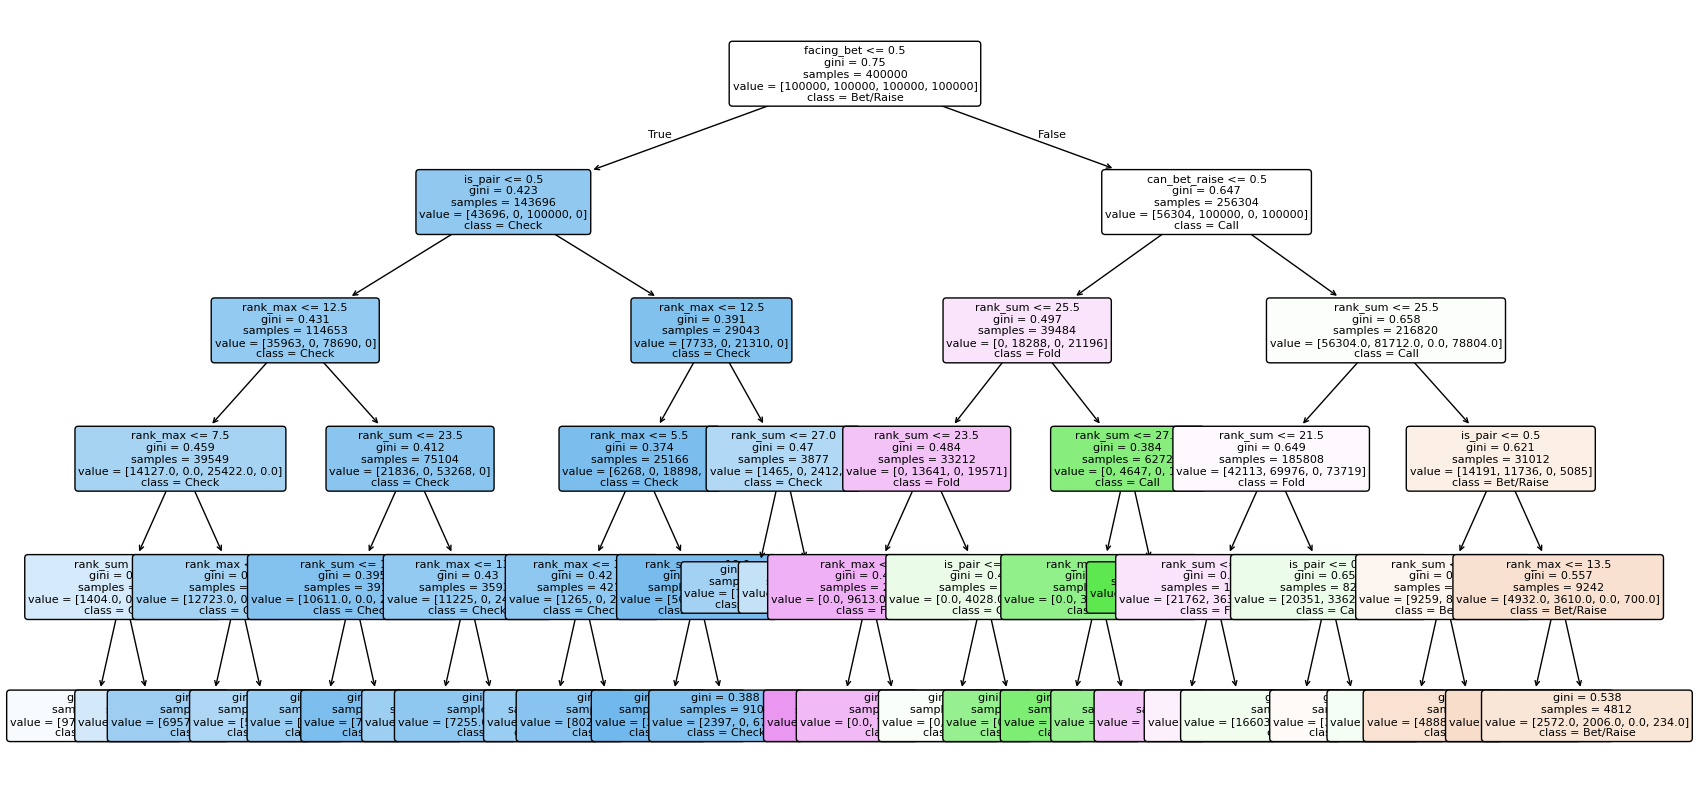

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))
plot_tree(
    clf,
    feature_names=X.columns,
    class_names=clf.classes_,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.show()

Basic Players (Hand Strength)

In [ ]:
df_hand_strength = df_own_hand.assign(
    holding=df['holding'],
    flop=df['board_flop'],
    turn=df['board_turn'],
    river=df['board_river'],
    street=df['evaluation_at'],
)

df_hand_strength.head()

,decision_category,is_pair,rank_sum,rank_max,facing_bet,can_bet_raise,holding,flop,turn,river,street
0,Check,0,27,14,0,1,AhKd,JcJh4s,4d,As,River
1,Call,0,19,10,1,1,Tc9c,6s8d7c,9s,3c,Turn
2,Call,1,24,12,1,0,QsQh,JcJh4s,4d,As,Turn
3,Check,0,21,11,0,1,JcTc,Th3s2d,5d,3c,River
4,Bet/Raise,0,19,14,0,1,Ac5c,Ks7h2d,Jc,Qc,River


In [ ]:
from itertools import combinations
from collections import Counter

RANK_VALUES = {
    '2': 2, '3': 3, '4': 4, '5': 5, '6': 6, '7': 7, '8': 8,
    '9': 9, 'T': 10, 'J': 11, 'Q': 12, 'K': 13, 'A': 14
}

HAND_RANKS = {
    'high_card': 1,
    'pair': 2,
    'two_pair': 3,
    'three_of_a_kind': 4,
    'straight': 5,
    'flush': 6,
    'full_house': 7,
    'four_of_a_kind': 8,
    'straight_flush': 9,
    'royal_flush': 10,
}

def parse_cards(card_string):
    if not isinstance(card_string, str) or card_string == '':
        return []
    return [(RANK_VALUES[card_string[i]], card_string[i+1])
            for i in range(0, len(card_string), 2)]

def evaluate_5_cards(cards):
    """Return a tuple (category, tiebreakers...) that sorts correctly vs other hands."""
    ranks = sorted([c[0] for c in cards], reverse=True)
    suits = [c[1] for c in cards]

    is_flush = len(set(suits)) == 1

    unique_ranks = sorted(set(ranks), reverse=True)
    is_straight = False
    straight_high = None
    if len(unique_ranks) == 5:
        if unique_ranks[0] - unique_ranks[4] == 4:
            is_straight = True
            straight_high = unique_ranks[0]
        elif unique_ranks == [14, 5, 4, 3, 2]:  # wheel: Ace plays low
            is_straight = True
            straight_high = 5

    # Count ranks, then sort by (count desc, rank desc)
    # e.g. KKK22 -> [(3, 13), (2, 2)]; AAKK7 -> [(2, 14), (2, 13), (1, 7)]
    count_rank = sorted(Counter(ranks).items(), key=lambda x: (-x[1], -x[0]))
    counts = [c for _, c in count_rank]
    rank_order = [r for r, _ in count_rank]

    if is_straight and is_flush:
        if straight_high == 14:
            return (HAND_RANKS['royal_flush'],)
        return (HAND_RANKS['straight_flush'], straight_high)
    if counts[0] == 4:
        # four of a kind: [quad_rank, kicker]
        return (HAND_RANKS['four_of_a_kind'], rank_order[0], rank_order[1])
    if counts == [3, 2]:
        # full house: [trip_rank, pair_rank]
        return (HAND_RANKS['full_house'], rank_order[0], rank_order[1])
    if is_flush:
        # flush: all 5 ranks, high to low
        return (HAND_RANKS['flush'], *ranks)
    if is_straight:
        return (HAND_RANKS['straight'], straight_high)
    if counts[0] == 3:
        # trips: [trip_rank, kicker1, kicker2]
        return (HAND_RANKS['three_of_a_kind'], rank_order[0], rank_order[1], rank_order[2])
    if counts == [2, 2, 1]:
        # two pair: [high_pair, low_pair, kicker]
        return (HAND_RANKS['two_pair'], rank_order[0], rank_order[1], rank_order[2])
    if counts[0] == 2:
        # pair: [pair_rank, kicker1, kicker2, kicker3]
        return (HAND_RANKS['pair'], rank_order[0], rank_order[1], rank_order[2], rank_order[3])
    # high card: all 5 ranks, high to low
    return (HAND_RANKS['high_card'], *ranks)

def best_hand_strength(holding, flop, turn, river, street):
    cards = parse_cards(holding) + parse_cards(flop)
    if street == 'Turn':
        cards += parse_cards(turn)
    elif street == 'River':
        cards += parse_cards(turn) + parse_cards(river)

    if len(cards) < 5:
        return None

    if len(cards) == 5:
        return evaluate_5_cards(cards)

    return max(evaluate_5_cards(list(combo)) for combo in combinations(cards, 5))

# Apply
df_hand_strength['hand_strength_tuple'] = df_hand_strength.apply(
    lambda row: best_hand_strength(
        row['holding'], row['flop'], row['turn'], row['river'], row['street']
    ),
    axis=1
)

In [ ]:
# Convert tuples to a single ordered rank (1 = worst, N = best)
df_hand_strength['hand_strength'] = (
    df_hand_strength['hand_strength_tuple']
    .rank(method='dense')
    .astype('Int64')  # nullable int, since Flop rows with no hand may be None
)

In [ ]:
from itertools import combinations, product

def test_hand_evaluator():
    # ---------- Test 1: Known hand rankings ----------
    # Each test case: (5-card hand, expected category)
    test_cases = [
        # Royal flush
        ([(14,'h'),(13,'h'),(12,'h'),(11,'h'),(10,'h')], 'royal_flush'),
        # Straight flush (9-high)
        ([(9,'s'),(8,'s'),(7,'s'),(6,'s'),(5,'s')], 'straight_flush'),
        # Wheel straight flush
        ([(14,'c'),(5,'c'),(4,'c'),(3,'c'),(2,'c')], 'straight_flush'),
        # Four of a kind
        ([(7,'h'),(7,'d'),(7,'c'),(7,'s'),(2,'h')], 'four_of_a_kind'),
        # Full house
        ([(10,'h'),(10,'d'),(10,'c'),(4,'s'),(4,'h')], 'full_house'),
        # Flush
        ([(14,'h'),(10,'h'),(7,'h'),(5,'h'),(2,'h')], 'flush'),
        # Straight
        ([(9,'s'),(8,'d'),(7,'c'),(6,'h'),(5,'s')], 'straight'),
        # Wheel straight
        ([(14,'s'),(5,'d'),(4,'c'),(3,'h'),(2,'s')], 'straight'),
        # Ace-high straight (Broadway)
        ([(14,'s'),(13,'d'),(12,'c'),(11,'h'),(10,'s')], 'straight'),
        # Three of a kind
        ([(8,'h'),(8,'d'),(8,'c'),(5,'s'),(2,'h')], 'three_of_a_kind'),
        # Two pair
        ([(13,'h'),(13,'d'),(7,'c'),(7,'s'),(2,'h')], 'two_pair'),
        # Pair
        ([(9,'h'),(9,'d'),(7,'c'),(5,'s'),(2,'h')], 'pair'),
        # High card
        ([(14,'h'),(11,'d'),(8,'c'),(5,'s'),(2,'h')], 'high_card'),
    ]
    for cards, expected in test_cases:
        result = evaluate_5_cards(cards)
        assert result[0] == HAND_RANKS[expected], \
            f"Expected {expected}, got category {result[0]} for {cards}"
    print(f"✓ All {len(test_cases)} category tests passed")

    # ---------- Test 2: Tiebreaker ordering ----------
    # Each pair: (stronger hand, weaker hand) — first should be > second
    ordering_cases = [
        # Higher pair beats lower pair
        ([(14,'h'),(14,'d'),(7,'c'),(5,'s'),(2,'h')],
         [(13,'h'),(13,'d'),(7,'c'),(5,'s'),(2,'h')]),
        # Same pair, better kicker wins
        ([(9,'h'),(9,'d'),(14,'c'),(5,'s'),(2,'h')],
         [(9,'h'),(9,'d'),(13,'c'),(5,'s'),(2,'h')]),
        # Higher flush wins
        ([(14,'h'),(10,'h'),(7,'h'),(5,'h'),(2,'h')],
         [(13,'h'),(10,'h'),(7,'h'),(5,'h'),(2,'h')]),
        # Wheel is the lowest straight
        ([(6,'s'),(5,'d'),(4,'c'),(3,'h'),(2,'s')],
         [(14,'s'),(5,'d'),(4,'c'),(3,'h'),(2,'s')]),
        # Broadway beats 9-high straight
        ([(14,'s'),(13,'d'),(12,'c'),(11,'h'),(10,'s')],
         [(9,'s'),(8,'d'),(7,'c'),(6,'h'),(5,'s')]),
        # Any straight flush beats any four of a kind
        ([(6,'s'),(5,'s'),(4,'s'),(3,'s'),(2,'s')],
         [(14,'h'),(14,'d'),(14,'c'),(14,'s'),(13,'h')]),
    ]
    for stronger, weaker in ordering_cases:
        s = evaluate_5_cards(stronger)
        w = evaluate_5_cards(weaker)
        assert s > w, f"Expected {stronger} > {weaker}, got {s} vs {w}"
    print(f"✓ All {len(ordering_cases)} ordering tests passed")

    # ---------- Test 3: Distinct equivalence class count ----------
    # Enumerate every rank combo × (suited vs non-suited) and collect distinct tuples.
    # For 5-card combos with no flush possible, suits don't affect the tuple.
    # For suited combos (all same suit), we get the flush-variant tuple.
    all_tuples = set()

    for rank_combo in combinations(range(2, 15), 5):
        # Non-flush version: use mixed suits so no flush
        mixed = [(r, s) for r, s in zip(rank_combo, ['h','d','c','s','h'])]
        all_tuples.add(evaluate_5_cards(mixed))
        # Flush version: all same suit
        suited = [(r, 'h') for r in rank_combo]
        all_tuples.add(evaluate_5_cards(suited))

    # Plus combos with duplicate ranks: pairs, trips, quads, full houses, two pairs
    # Pairs: pair rank + 3 distinct kickers
    for pair_r in range(2, 15):
        for kickers in combinations([r for r in range(2, 15) if r != pair_r], 3):
            hand = [(pair_r,'h'),(pair_r,'d')] + [(k,'c') for k in kickers]
            # Adjust suits so no flush
            hand = [(r, s) for (r, _), s in zip(hand, ['h','d','c','s','h'])]
            all_tuples.add(evaluate_5_cards(hand))

    # Two pair
    for pairs in combinations(range(2, 15), 2):
        for kicker in [r for r in range(2, 15) if r not in pairs]:
            hand = [(pairs[0],'h'),(pairs[0],'d'),(pairs[1],'c'),(pairs[1],'s'),(kicker,'h')]
            all_tuples.add(evaluate_5_cards(hand))

    # Trips
    for trip_r in range(2, 15):
        for kickers in combinations([r for r in range(2, 15) if r != trip_r], 2):
            hand = [(trip_r,'h'),(trip_r,'d'),(trip_r,'c'),(kickers[0],'s'),(kickers[1],'h')]
            all_tuples.add(evaluate_5_cards(hand))

    # Full houses
    for trip_r in range(2, 15):
        for pair_r in range(2, 15):
            if pair_r == trip_r: continue
            hand = [(trip_r,'h'),(trip_r,'d'),(trip_r,'c'),(pair_r,'s'),(pair_r,'h')]
            all_tuples.add(evaluate_5_cards(hand))

    # Quads
    for quad_r in range(2, 15):
        for kicker in [r for r in range(2, 15) if r != quad_r]:
            hand = [(quad_r,'h'),(quad_r,'d'),(quad_r,'c'),(quad_r,'s'),(kicker,'h')]
            all_tuples.add(evaluate_5_cards(hand))

    print(f"Distinct hand-strength tuples found: {len(all_tuples)}")
    assert len(all_tuples) == 7462, f"Expected 7462, got {len(all_tuples)}"
    print("✓ Distinct-class count matches theoretical 7,462")

test_hand_evaluator()

✓ All 13 category tests passed
✓ All 6 ordering tests passed
Distinct hand-strength tuples found: 7462
✓ Distinct-class count matches theoretical 7,462


In [ ]:
CATEGORY_NAMES = {v: k for k, v in HAND_RANKS.items()}
STREET_VALUES = {'Flop': 1, 'Turn': 2, 'River': 3}

keep_cols = ['decision_category', 'is_pair', 'rank_sum', 'rank_max',
             'can_bet_raise', 'facing_bet']

df_hand_strength_final = df_hand_strength[keep_cols].copy()
df_hand_strength_final['hand_category'] = df_hand_strength['hand_strength_tuple'].apply(
    lambda t: CATEGORY_NAMES[t[0]] if t is not None else None
)
df_hand_strength_final['hand_rank'] = df_hand_strength['hand_strength']
df_hand_strength_final['street'] = df_hand_strength['street'].map(STREET_VALUES)
df_hand_strength_final.head()

,decision_category,is_pair,rank_sum,rank_max,can_bet_raise,facing_bet,hand_category,hand_rank,street
0,Check,0,27,14,1,0,two_pair,2523,3
1,Call,0,19,10,1,1,straight,2829,2
2,Call,1,24,12,0,1,two_pair,2388,2
3,Check,0,21,11,1,0,two_pair,2245,3
4,Bet/Raise,0,19,14,1,0,high_card,711,3


In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

# Drop the string category
df_hand_strength_final = df_hand_strength_final.drop(columns=['hand_category'])

# Define features and target
feature_cols = ['is_pair', 'rank_sum', 'rank_max',
                'can_bet_raise', 'facing_bet',
                'hand_rank', 'street']
X = df_hand_strength_final[feature_cols]
y = df_hand_strength_final['decision_category']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train
clf = DecisionTreeClassifier(max_depth=5, random_state=42)
clf.fit(X_train, y_train)

# Evaluate
train_acc = accuracy_score(y_train, clf.predict(X_train))
test_acc = accuracy_score(y_test, clf.predict(X_test))

print(f"Training accuracy: {train_acc:.4f} ({train_acc*100:.2f}%)")
print(f"Test accuracy:     {test_acc:.4f} ({test_acc*100:.2f}%)")

Training accuracy: 0.6363 (63.63%)
Test accuracy:     0.6368 (63.68%)


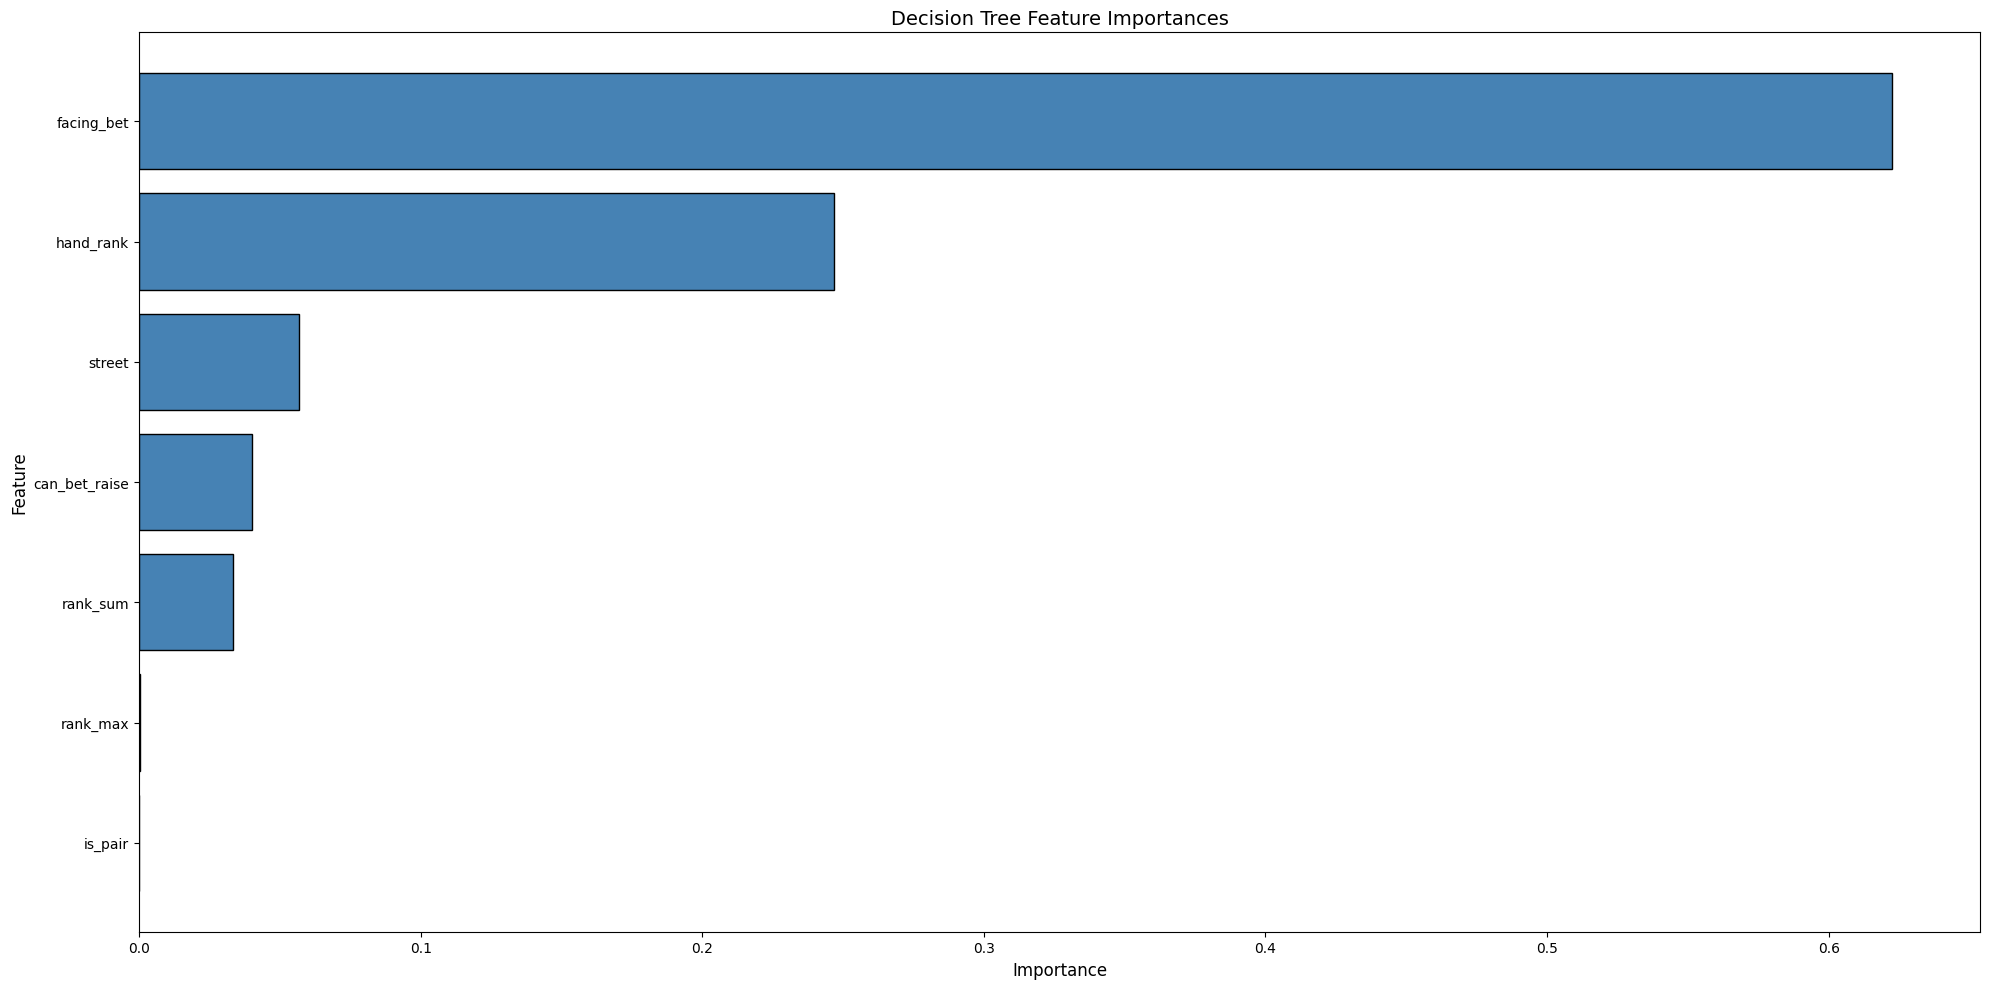

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Sort features by importance
indices = np.argsort(clf.feature_importances_)[::-1]
sorted_features = [feature_cols[i] for i in indices]
sorted_importances = clf.feature_importances_[indices]

plt.figure(figsize=(20, 10))
plt.barh(sorted_features[::-1], sorted_importances[::-1], color='steelblue', edgecolor='black')
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Decision Tree Feature Importances', fontsize=14)
plt.tight_layout()
plt.show()

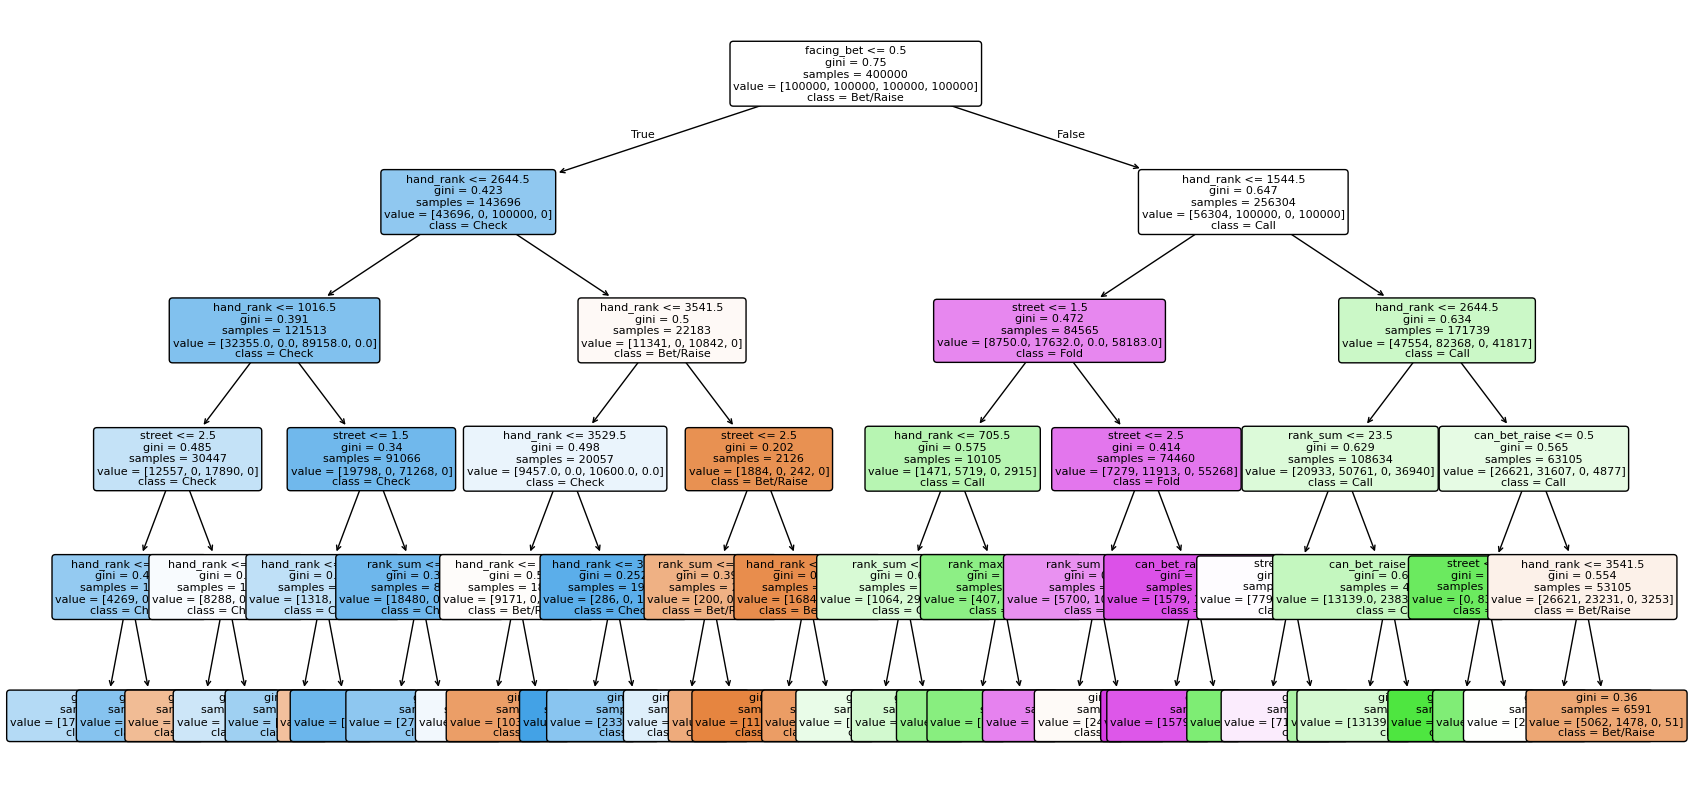

In [ ]:
# Visualize the tree
plt.figure(figsize=(20, 10))
plot_tree(
    clf,
    feature_names=X.columns,
    class_names=clf.classes_,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.show()

Basic Players (Max Strength)

In [ ]:
from itertools import combinations
from collections import Counter
from tqdm import tqdm

ALL_SUITS = ['h', 'd', 'c', 's']
ALL_RANKS = list(RANK_VALUES.keys())
FULL_DECK = [r + s for r in ALL_RANKS for s in ALL_SUITS]

def cards_to_strings(card_string):
    """Split 'JcJh4s' into ['Jc', 'Jh', '4s']."""
    if not isinstance(card_string, str) or card_string == '':
        return []
    return [card_string[i:i+2] for i in range(0, len(card_string), 2)]

def max_future_strength_fast(holding, flop, turn, river, street):
    """Determine best reachable hand category by checking draws, not enumerating boards."""
    known = cards_to_strings(holding) + cards_to_strings(flop)
    if street == 'Turn':
        known += cards_to_strings(turn)
    elif street == 'River':
        known += cards_to_strings(turn) + cards_to_strings(river)

    cards_needed = 7 - len(known)

    parsed = [(RANK_VALUES[c[0]], c[1]) for c in known]
    ranks = [r for r, _ in parsed]
    suits = [s for _, s in parsed]
    rank_counts = Counter(ranks)
    suit_counts = Counter(suits)

    if cards_needed == 0:
        return max(evaluate_5_cards(list(combo)) for combo in combinations(parsed, 5))

    # --- Royal flush
    for suit in ALL_SUITS:
        have = {r for r, s in parsed if s == suit}
        need = {14, 13, 12, 11, 10} - have
        if len(need) <= cards_needed:
            return (HAND_RANKS['royal_flush'],)

    # --- Straight flush
    best_sf_high = 0
    for suit in ALL_SUITS:
        have = {r for r, s in parsed if s == suit}
        for high in range(14, 5, -1):
            needed_ranks = set(range(high - 4, high + 1))
            missing = needed_ranks - have
            if len(missing) <= cards_needed:
                best_sf_high = max(best_sf_high, high)
                break
        if 14 in have or 14 not in have:
            wheel = {14, 2, 3, 4, 5}
            if len(wheel - have) <= cards_needed and best_sf_high == 0:
                best_sf_high = max(best_sf_high, 5)
    if best_sf_high > 0:
        return (HAND_RANKS['straight_flush'], best_sf_high)

    # --- Four of a kind
    for r in range(14, 1, -1):
        if 4 - rank_counts.get(r, 0) <= cards_needed:
            other_ranks = [rr for rr in ranks if rr != r]
            if cards_needed > (4 - rank_counts.get(r, 0)):
                kicker = 14
            else:
                kicker = max(other_ranks) if other_ranks else 2
            return (HAND_RANKS['four_of_a_kind'], r, kicker)

    # --- Full house
    best_fh = None
    for trip_r in range(14, 1, -1):
        trip_need = max(0, 3 - rank_counts.get(trip_r, 0))
        if trip_need > cards_needed:
            continue
        remaining_draws = cards_needed - trip_need
        for pair_r in range(14, 1, -1):
            if pair_r == trip_r:
                continue
            pair_need = max(0, 2 - rank_counts.get(pair_r, 0))
            if pair_need <= remaining_draws:
                best_fh = (HAND_RANKS['full_house'], trip_r, pair_r)
                break
        if best_fh:
            break
    current_check = best_fh if best_fh else None

    # --- Flush
    best_flush = None
    for suit in ALL_SUITS:
        have = sorted([r for r, s in parsed if s == suit], reverse=True)
        need = max(0, 5 - len(have))
        if need <= cards_needed:
            drawn_ranks = []
            used = set(have)
            for r in range(14, 1, -1):
                if len(drawn_ranks) >= need:
                    break
                if r not in used:
                    drawn_ranks.append(r)
                    used.add(r)
            flush_ranks = sorted(have + drawn_ranks, reverse=True)[:5]
            candidate = (HAND_RANKS['flush'], *flush_ranks)
            if best_flush is None or candidate > best_flush:
                best_flush = candidate

    if current_check and best_flush:
        return max(current_check, best_flush)
    if current_check:
        return current_check
    if best_flush:
        return best_flush

    # --- Straight
    rank_set = set(ranks)
    best_straight_high = 0
    for high in range(14, 5, -1):
        needed_ranks = set(range(high - 4, high + 1))
        if len(needed_ranks - rank_set) <= cards_needed:
            best_straight_high = high
            break
    if best_straight_high == 0:
        wheel = {14, 2, 3, 4, 5}
        if len(wheel - rank_set) <= cards_needed:
            best_straight_high = 5
    if best_straight_high > 0:
        return (HAND_RANKS['straight'], best_straight_high)

    # --- Three of a kind
    for r in range(14, 1, -1):
        if 3 - rank_counts.get(r, 0) <= cards_needed:
            needed_for_trip = max(0, 3 - rank_counts.get(r, 0))
            spare = cards_needed - needed_for_trip
            other = sorted([rr for rr in ranks if rr != r], reverse=True)
            kickers = (other + [14, 13])[:2] if spare >= 2 else (other + [14])[:2] if spare >= 1 else other[:2]
            kickers = (kickers + [2, 2])[:2]
            return (HAND_RANKS['three_of_a_kind'], r, kickers[0], kickers[1])

    # --- Two pair
    best_tp = None
    for high_r in range(14, 1, -1):
        high_need = max(0, 2 - rank_counts.get(high_r, 0))
        if high_need > cards_needed:
            continue
        for low_r in range(high_r - 1, 1, -1):
            low_need = max(0, 2 - rank_counts.get(low_r, 0))
            if high_need + low_need <= cards_needed:
                best_tp = (HAND_RANKS['two_pair'], high_r, low_r, 14)
                break
        if best_tp:
            break
    if best_tp:
        return best_tp

    # --- Pair
    for r in range(14, 1, -1):
        if 2 - rank_counts.get(r, 0) <= cards_needed:
            return (HAND_RANKS['pair'], r, 14, 13, 12)

    return (HAND_RANKS['high_card'], 14, 13, 12, 11, 10)

In [ ]:
# Enable tqdm for pandas .progress_apply
tqdm.pandas(desc="Computing max future strength")

df_max_strength = df_hand_strength.assign(
    max_future_tuple=df_hand_strength.progress_apply(
        lambda row: max_future_strength_fast(
            row['holding'], row['flop'], row['turn'], row['river'], row['street']
        ),
        axis=1
    )
)

Computing max future strength: 100%|██████████| 500000/500000 [00:41<00:00, 11969.84it/s]


In [ ]:
# Combine all tuples from both columns into one pool and rank them together
all_tuples = pd.concat([
    df_max_strength['hand_strength_tuple'],
    df_max_strength['max_future_tuple']
])
unified_ranks = all_tuples.rank(method='dense').astype('Int64')

# Split back into the two columns — first half is hand, second half is max_future
n = len(df_max_strength)
df_max_strength['hand_rank'] = unified_ranks.iloc[:n].values
df_max_strength['max_future_rank'] = unified_ranks.iloc[n:].values

In [ ]:
# Pull the current-hand columns over from df_hand_strength for comparison
test_df = df_max_strength[['holding', 'flop', 'turn', 'river', 'street',
                            'max_future_tuple', 'max_future_rank']].copy()
test_df['hand_strength_tuple'] = df_hand_strength['hand_strength_tuple']
test_df['hand_rank'] = df_hand_strength['hand_strength']  # this is the scalar rank from earlier

# --- Test 1: max future tuple is always >= current tuple (lexicographic) ---
violations = test_df[test_df.apply(
    lambda r: r['max_future_tuple'] < r['hand_strength_tuple'], axis=1
)]
assert len(violations) == 0, f"Found {len(violations)} rows where future < current:\n{violations.head()}"
print(f"✓ max_future_tuple >= hand_strength_tuple for all {len(test_df)} rows")

# --- Test 2: on River rows, max future should equal current ---
river_rows = test_df[test_df['street'] == 'River']
river_mismatches = river_rows[
    river_rows['hand_strength_tuple'] != river_rows['max_future_tuple']
]
assert len(river_mismatches) == 0, \
    f"Found {len(river_mismatches)} River rows where max_future != current:\n{river_mismatches.head()}"
print(f"✓ max_future == current on all {len(river_rows)} River rows")

# --- Test 3: max_future_rank has no nulls ---
n_null = test_df['max_future_rank'].isna().sum()
assert n_null == 0, f"Found {n_null} null max_future_rank values"
print(f"✓ max_future_rank has no nulls")

# --- Test 4: Flop rows should often show improvement ---
flop_rows = test_df[test_df['street'] == 'Flop']
if len(flop_rows) > 0:
    improved = flop_rows[flop_rows['max_future_tuple'] > flop_rows['hand_strength_tuple']]
    pct_improved = 100 * len(improved) / len(flop_rows)
    print(f"ℹ {pct_improved:.1f}% of Flop rows show strict improvement ({len(improved)}/{len(flop_rows)})")
    assert pct_improved > 50, "Suspiciously few Flop rows improved — check logic"

# --- Test 5: every category should be in the valid range ---
categories = test_df['max_future_tuple'].apply(lambda t: t[0])
assert categories.min() >= 1 and categories.max() <= 10, \
    f"Invalid category range: {categories.min()} to {categories.max()}"
print(f"✓ All categories in valid range [1, 10]")

# --- Test 6: Every Flop row can reach at least a pair ---
if len(flop_rows) > 0:
    flop_min_cat = flop_rows['max_future_tuple'].apply(lambda t: t[0]).min()
    assert flop_min_cat >= HAND_RANKS['pair'], \
        f"Found a Flop row with max future < pair (category {flop_min_cat}) — impossible with 2 draws"
    print(f"✓ Every Flop row can reach at least a pair (min category: {flop_min_cat})")

print("\nAll tests passed!")

✓ max_future_tuple >= hand_strength_tuple for all 500000 rows
✓ max_future == current on all 260419 River rows
✓ max_future_rank has no nulls
ℹ 99.7% of Flop rows show strict improvement (32324/32428)
✓ All categories in valid range [1, 10]
✓ Every Flop row can reach at least a pair (min category: 4)

All tests passed!


In [ ]:
df_max_strength_final = df_hand_strength_final.copy()
df_max_strength_final['max_future_rank'] = df_max_strength['max_future_rank']
df_max_strength_final['hand_rank'] = df_max_strength['hand_rank']

df_max_strength_final.head()

,decision_category,is_pair,rank_sum,rank_max,can_bet_raise,facing_bet,hand_rank,street,max_future_rank
0,Check,0,27,14,1,0,2526,3,2526
1,Call,0,19,10,1,1,2905,2,2906
2,Call,1,24,12,0,1,2391,2,3836
3,Check,0,21,11,1,0,2248,3,2248
4,Bet/Raise,0,19,14,1,0,711,3,711


In [ ]:
# Define features and target
feature_cols = ['is_pair', 'rank_sum', 'rank_max',
                'can_bet_raise', 'facing_bet',
                'hand_rank', 'max_future_rank', 'street']
X = df_max_strength_final[feature_cols]
y = df_max_strength_final['decision_category']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train
clf = DecisionTreeClassifier(max_depth=5, random_state=42)
clf.fit(X_train, y_train)

# Evaluate
train_acc = accuracy_score(y_train, clf.predict(X_train))
test_acc = accuracy_score(y_test, clf.predict(X_test))

print(f"Training accuracy: {train_acc:.4f} ({train_acc*100:.2f}%)")
print(f"Test accuracy:     {test_acc:.4f} ({test_acc*100:.2f}%)")

Training accuracy: 0.6491 (64.91%)
Test accuracy:     0.6486 (64.86%)


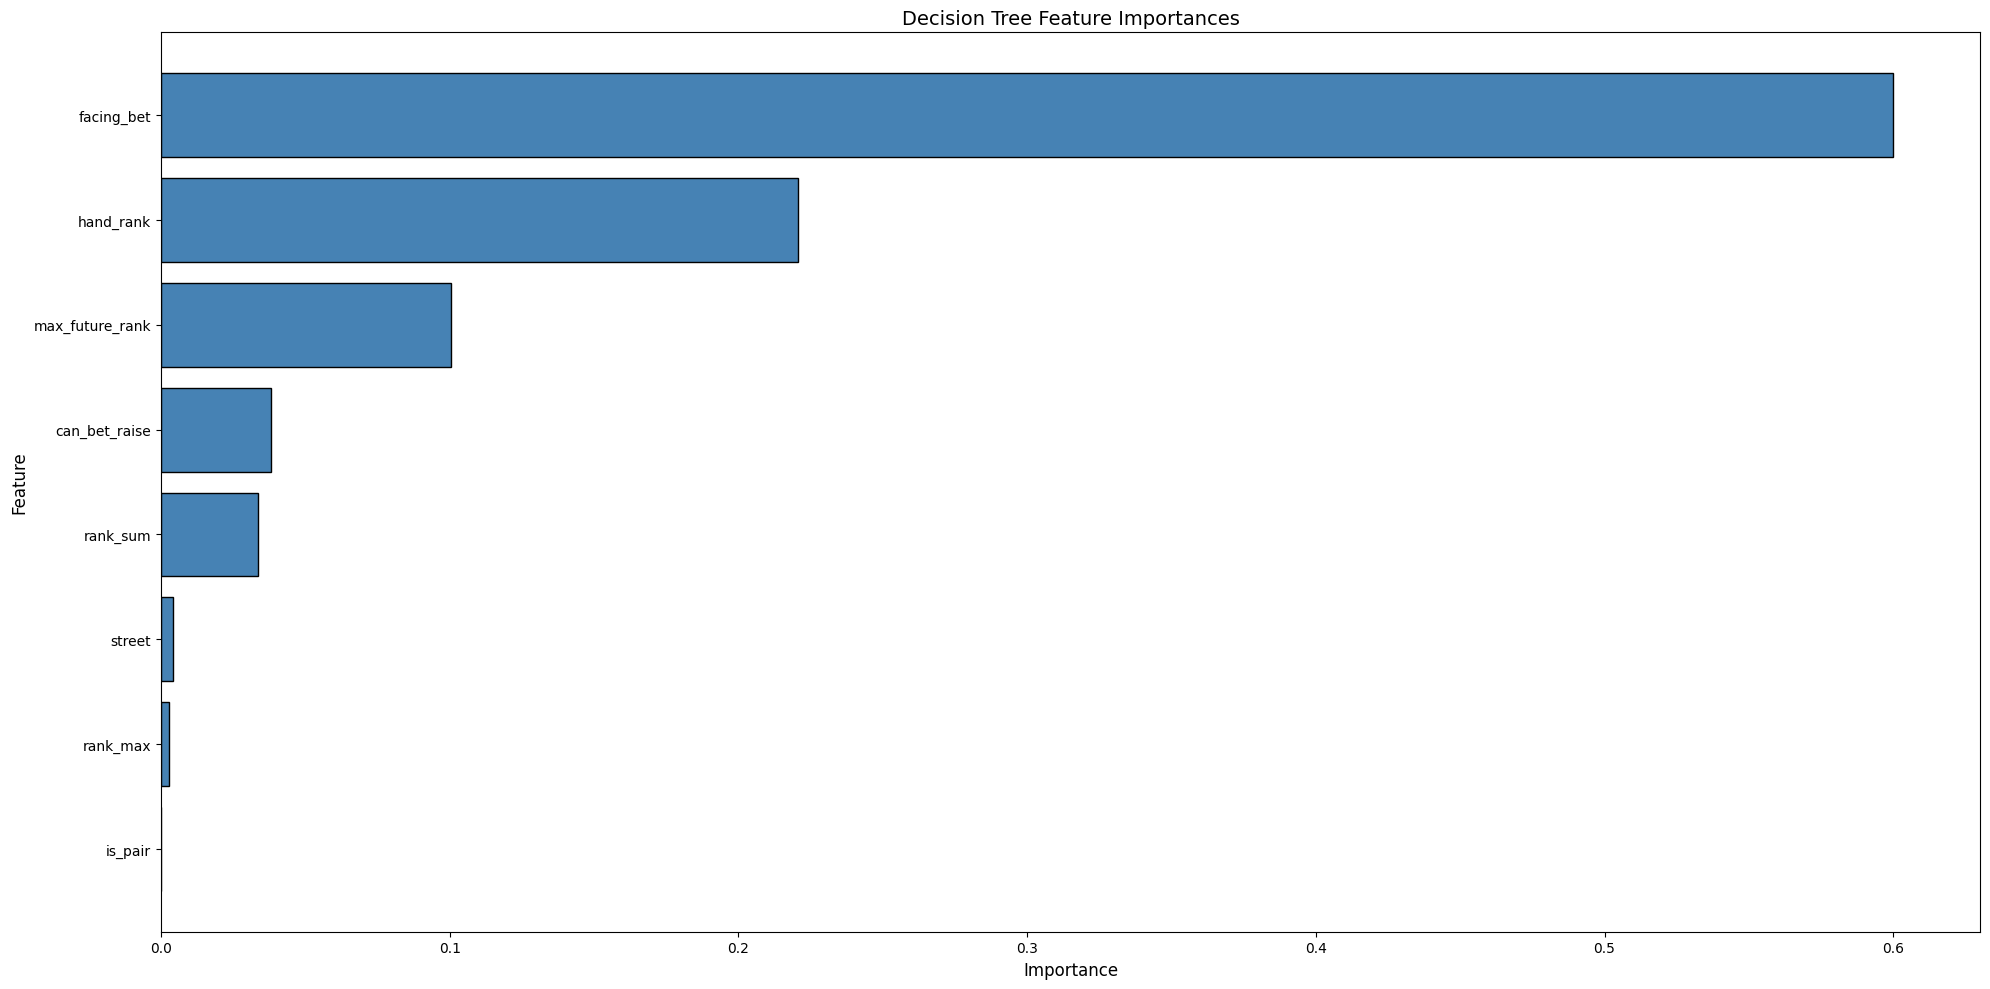

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Sort features by importance
indices = np.argsort(clf.feature_importances_)[::-1]
sorted_features = [feature_cols[i] for i in indices]
sorted_importances = clf.feature_importances_[indices]

plt.figure(figsize=(20, 10))
plt.barh(sorted_features[::-1], sorted_importances[::-1], color='steelblue', edgecolor='black')
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Decision Tree Feature Importances', fontsize=14)
plt.tight_layout()
plt.show()

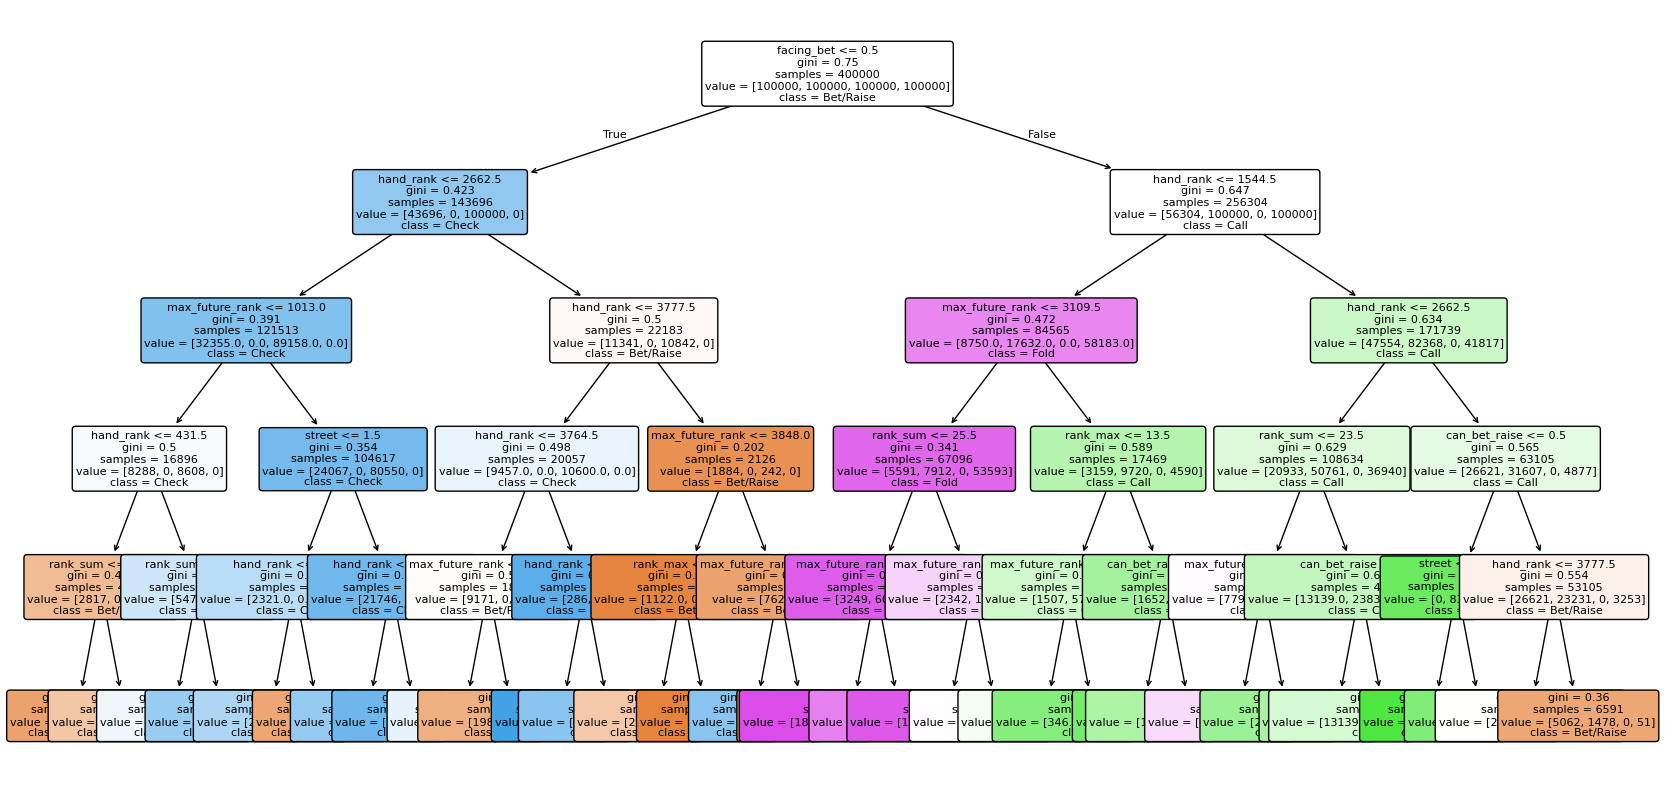

In [ ]:
# Visualize the tree
plt.figure(figsize=(20, 10))
plot_tree(
    clf,
    feature_names=X.columns,
    class_names=clf.classes_,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.show()

Intermediate Players (Board Strength)

In [ ]:
def nut_strength(holding, flop, turn, river, street):
    """Best possible hand any opponent could hold, given board + our blockers.
    Opponent has 2 unknown cards; future board cards are also unknown."""
    my_hole = cards_to_strings(holding)
    board_known = cards_to_strings(flop)
    if street == 'Turn':
        board_known += cards_to_strings(turn)
        future_board = 1
    elif street == 'River':
        board_known += cards_to_strings(turn) + cards_to_strings(river)
        future_board = 0
    else:  # Flop
        future_board = 2

    # Cards the opponent CANNOT have (we hold them or they're on the board)
    blocked = set(my_hole + board_known)
    # Available cards the opponent could be dealt from
    available = [c for c in FULL_DECK if c not in blocked]

    # The opponent chooses 2 cards from `available`, and `future_board` more
    # board cards come from the remaining deck. Total "helpful" unknowns for the
    # opponent: 2 (hole) + future_board (shared future board).
    opp_cards_needed = 2 + future_board

    # Parse what's already on the board (everyone shares these)
    board_parsed = [(RANK_VALUES[c[0]], c[1]) for c in board_known]

    # Helper: given a target rank-and-suit set the opponent needs, how many of
    # those ranks/suits are still available in `available` (opponent's possible hole cards)?
    avail_by_rank = Counter(RANK_VALUES[c[0]] for c in available)
    avail_by_suit_rank = {s: {RANK_VALUES[c[0]] for c in available if c[1] == s} for s in ALL_SUITS}

    board_rank_counts = Counter(r for r, _ in board_parsed)
    board_rank_set = set(board_rank_counts)
    board_by_suit = {s: {r for r, ss in board_parsed if ss == s} for s in ALL_SUITS}

    def can_get_ranks(needed_ranks, max_from_opp):
        """Can the opponent + future board collectively produce each of `needed_ranks`?
        `needed_ranks` is a set of ranks not yet on the board.
        `max_from_opp` is how many of the missing ranks must come from opp's hole cards
        (if future_board is 0, all missing ranks come from opp; otherwise future board can fill some).
        Returns True if achievable, respecting that opp has exactly 2 hole cards
        and future_board shared cards fill the rest."""
        missing = needed_ranks - board_rank_set
        total_slots = 2 + future_board
        if len(missing) > total_slots:
            return False
        # For each missing rank, at least one card of that rank must exist in the remaining deck
        for r in missing:
            if avail_by_rank.get(r, 0) == 0:
                return False
        return True

    def can_get_suited(needed_suit, needed_ranks):
        """Can opp+board collectively get 5 of `needed_suit` with those specific ranks?"""
        have = board_by_suit[needed_suit]
        missing = needed_ranks - have
        total_slots = 2 + future_board
        if len(missing) > total_slots:
            return False
        # Each missing (rank, suit) must be in opp's available pool
        for r in missing:
            if r not in avail_by_suit_rank[needed_suit]:
                return False
        return True

    # --- Royal flush
    for suit in ALL_SUITS:
        if can_get_suited(suit, {14, 13, 12, 11, 10}):
            return (HAND_RANKS['royal_flush'],)

    # --- Straight flush
    best_sf_high = 0
    for suit in ALL_SUITS:
        for high in range(14, 5, -1):
            if can_get_suited(suit, set(range(high - 4, high + 1))):
                best_sf_high = max(best_sf_high, high)
                break
        if can_get_suited(suit, {14, 2, 3, 4, 5}) and best_sf_high < 5:
            best_sf_high = max(best_sf_high, 5)
    if best_sf_high > 0:
        return (HAND_RANKS['straight_flush'], best_sf_high)

    # --- Four of a kind
    for r in range(14, 1, -1):
        board_have = board_rank_counts.get(r, 0)
        need = 4 - board_have
        # Need `need` more cards of this rank, and they must be in remaining deck
        if need <= (2 + future_board) and avail_by_rank.get(r, 0) >= need:
            # Kicker: highest rank opp could also hold/fill
            kicker = 14 if avail_by_rank.get(14, 0) > 0 else max(
                (rr for rr in range(14, 1, -1) if rr != r and avail_by_rank.get(rr, 0) > 0),
                default=2
            )
            return (HAND_RANKS['four_of_a_kind'], r, kicker)

    # --- Full house
    best_fh = None
    for trip_r in range(14, 1, -1):
        trip_need = max(0, 3 - board_rank_counts.get(trip_r, 0))
        if trip_need > (2 + future_board) or avail_by_rank.get(trip_r, 0) < trip_need:
            continue
        for pair_r in range(14, 1, -1):
            if pair_r == trip_r:
                continue
            pair_need = max(0, 2 - board_rank_counts.get(pair_r, 0))
            if trip_need + pair_need <= (2 + future_board) and avail_by_rank.get(pair_r, 0) >= pair_need:
                best_fh = (HAND_RANKS['full_house'], trip_r, pair_r)
                break
        if best_fh:
            break

    # --- Flush
    best_flush = None
    for suit in ALL_SUITS:
        have = sorted(board_by_suit[suit], reverse=True)
        need = max(0, 5 - len(have))
        if need <= (2 + future_board):
            # Fill with highest available ranks of that suit
            pool = sorted(avail_by_suit_rank[suit], reverse=True)
            if len(pool) >= need:
                top_fill = pool[:need]
                flush_ranks = sorted(have + top_fill, reverse=True)[:5]
                candidate = (HAND_RANKS['flush'], *flush_ranks)
                if best_flush is None or candidate > best_flush:
                    best_flush = candidate

    if best_fh and best_flush:
        return max(best_fh, best_flush)
    if best_fh:
        return best_fh
    if best_flush:
        return best_flush

    # --- Straight
    best_straight_high = 0
    for high in range(14, 5, -1):
        needed = set(range(high - 4, high + 1))
        if can_get_ranks(needed, 2 + future_board):
            best_straight_high = high
            break
    if best_straight_high == 0 and can_get_ranks({14, 2, 3, 4, 5}, 2 + future_board):
        best_straight_high = 5
    if best_straight_high > 0:
        return (HAND_RANKS['straight'], best_straight_high)

    # --- Three of a kind
    for r in range(14, 1, -1):
        need = max(0, 3 - board_rank_counts.get(r, 0))
        if need <= (2 + future_board) and avail_by_rank.get(r, 0) >= need:
            return (HAND_RANKS['three_of_a_kind'], r, 14, 13)

    # --- Two pair
    for high_r in range(14, 1, -1):
        hn = max(0, 2 - board_rank_counts.get(high_r, 0))
        if hn > (2 + future_board) or avail_by_rank.get(high_r, 0) < hn:
            continue
        for low_r in range(high_r - 1, 1, -1):
            ln = max(0, 2 - board_rank_counts.get(low_r, 0))
            if hn + ln <= (2 + future_board) and avail_by_rank.get(low_r, 0) >= ln:
                return (HAND_RANKS['two_pair'], high_r, low_r, 14)

    # --- Pair
    for r in range(14, 1, -1):
        need = max(0, 2 - board_rank_counts.get(r, 0))
        if need <= (2 + future_board) and avail_by_rank.get(r, 0) >= need:
            return (HAND_RANKS['pair'], r, 14, 13, 12)

    # --- High card (edge case)
    return (HAND_RANKS['high_card'], 14, 13, 12, 11, 10)

In [ ]:
# Enable tqdm for pandas .progress_apply
tqdm.pandas(desc="Computing nut strength")

df_nut_strength = df_max_strength.assign(
    nut_tuple=df_max_strength.progress_apply(
        lambda row: nut_strength(
            row['holding'], row['flop'], row['turn'], row['river'], row['street']
        ),
        axis=1
    )
)
df_nut_strength['opponent_nut_rank'] = (
    df_nut_strength['nut_tuple'].rank(method='dense').astype('Int64')
)

Computing nut strength: 100%|██████████| 500000/500000 [00:29<00:00, 16753.22it/s]


In [ ]:
all_tuples = pd.concat([
    df_nut_strength['hand_strength_tuple'],
    df_nut_strength['max_future_tuple'],
    df_nut_strength['nut_tuple']
])
unified_ranks = all_tuples.rank(method='dense').astype('Int64')

n = len(df_nut_strength)
df_nut_strength['hand_rank'] = unified_ranks.iloc[:n].values
df_nut_strength['max_future_rank'] = unified_ranks.iloc[n:2*n].values
df_nut_strength['nut_rank'] = unified_ranks.iloc[2*n:].values

In [ ]:
# --- Test 1: Player's max_future vs nut — blocker cases are expected, especially on the river ---
# The nuts is the best hand an opponent could hold. When you hold key cards,
# you can legitimately draw to (or make) a hand no opponent can match.
# This effect is strongest on the river, where no future cards can bail opponents out.
blocker_rows = df_nut_strength[df_nut_strength['max_future_tuple'] > df_nut_strength['nut_tuple']]
print(f"ℹ Found {len(blocker_rows)} rows where player's max_future > nuts (blocker effect — expected)")
if len(blocker_rows) > 0:
    print("Blocker cases by street:")
    print(blocker_rows['street'].value_counts())

# Categorical gap check, tolerant of river blocker effects
def category_gap(row):
    return row['max_future_tuple'][0] - row['nut_tuple'][0]

df_nut_strength['_gap'] = df_nut_strength.apply(category_gap, axis=1)

# On Flop/Turn, expect tight relationship — big gaps suggest bugs
non_river_bad = df_nut_strength[
    (df_nut_strength['street'] != 'River') & (df_nut_strength['_gap'] > 2)
]
assert len(non_river_bad) == 0, \
    f"Found {len(non_river_bad)} non-River rows with category gap >2 — likely bug:\n" \
    f"{non_river_bad[['holding','flop','turn','river','street','max_future_tuple','nut_tuple']].head()}"
print(f"✓ No Flop/Turn rows with category gap >2")

# On River, allow larger gaps (blockers can create big category differences)
# but flag anything wildly out of the expected blocker range (>4 is very suspicious)
river_big_gap = df_nut_strength[
    (df_nut_strength['street'] == 'River') & (df_nut_strength['_gap'] > 4)
]
assert len(river_big_gap) == 0, \
    f"Found {len(river_big_gap)} River rows with category gap >4 — investigate:\n" \
    f"{river_big_gap[['holding','flop','turn','river','max_future_tuple','nut_tuple']].head()}"

# Report the River gap distribution for visibility
river_gaps = df_nut_strength[df_nut_strength['street'] == 'River']['_gap']
river_gap_dist = river_gaps[river_gaps > 0].value_counts().sort_index()
if len(river_gap_dist) > 0:
    print(f"ℹ River blocker-gap distribution:")
    print(river_gap_dist.to_string())

df_nut_strength = df_nut_strength.drop(columns=['_gap'])
print(f"✓ River blocker gaps within expected range (≤4)")

ℹ Found 10716 rows where player's max_future > nuts (blocker effect — expected)
Blocker cases by street:
street
Turn     5373
River    3738
Flop     1605
Name: count, dtype: int64
✓ No Flop/Turn rows with category gap >2
ℹ River blocker-gap distribution:
_gap
1    764
3    166
✓ River blocker gaps within expected range (≤4)


In [ ]:
df_nut_strength_final = df_max_strength_final.copy()
df_nut_strength_final['opponent_nut_rank'] = df_nut_strength['opponent_nut_rank']
df_nut_strength_final['hand_rank'] = df_nut_strength['hand_rank']
df_nut_strength_final['max_future_rank'] = df_nut_strength['max_future_rank']

df_nut_strength_final.head()

,decision_category,is_pair,rank_sum,rank_max,can_bet_raise,facing_bet,hand_rank,street,max_future_rank,opponent_nut_rank
0,Check,0,27,14,1,0,2526,3,2526,125
1,Call,0,19,10,1,1,2906,2,2907,135
2,Call,1,24,12,0,1,2391,2,3837,125
3,Check,0,21,11,1,0,2248,3,2248,117
4,Bet/Raise,0,19,14,1,0,711,3,711,12


In [ ]:
# Define features and target
feature_cols = ['is_pair', 'rank_sum', 'rank_max',
                'can_bet_raise', 'facing_bet',
                'hand_rank', 'max_future_rank', 'street', 'opponent_nut_rank']
X = df_nut_strength_final[feature_cols]
y = df_nut_strength_final['decision_category']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train
clf = DecisionTreeClassifier(max_depth=5, random_state=42)
clf.fit(X_train, y_train)

# Evaluate
train_acc = accuracy_score(y_train, clf.predict(X_train))
test_acc = accuracy_score(y_test, clf.predict(X_test))

print(f"Training accuracy: {train_acc:.4f} ({train_acc*100:.2f}%)")
print(f"Test accuracy:     {test_acc:.4f} ({test_acc*100:.2f}%)")

Training accuracy: 0.6491 (64.91%)
Test accuracy:     0.6485 (64.85%)


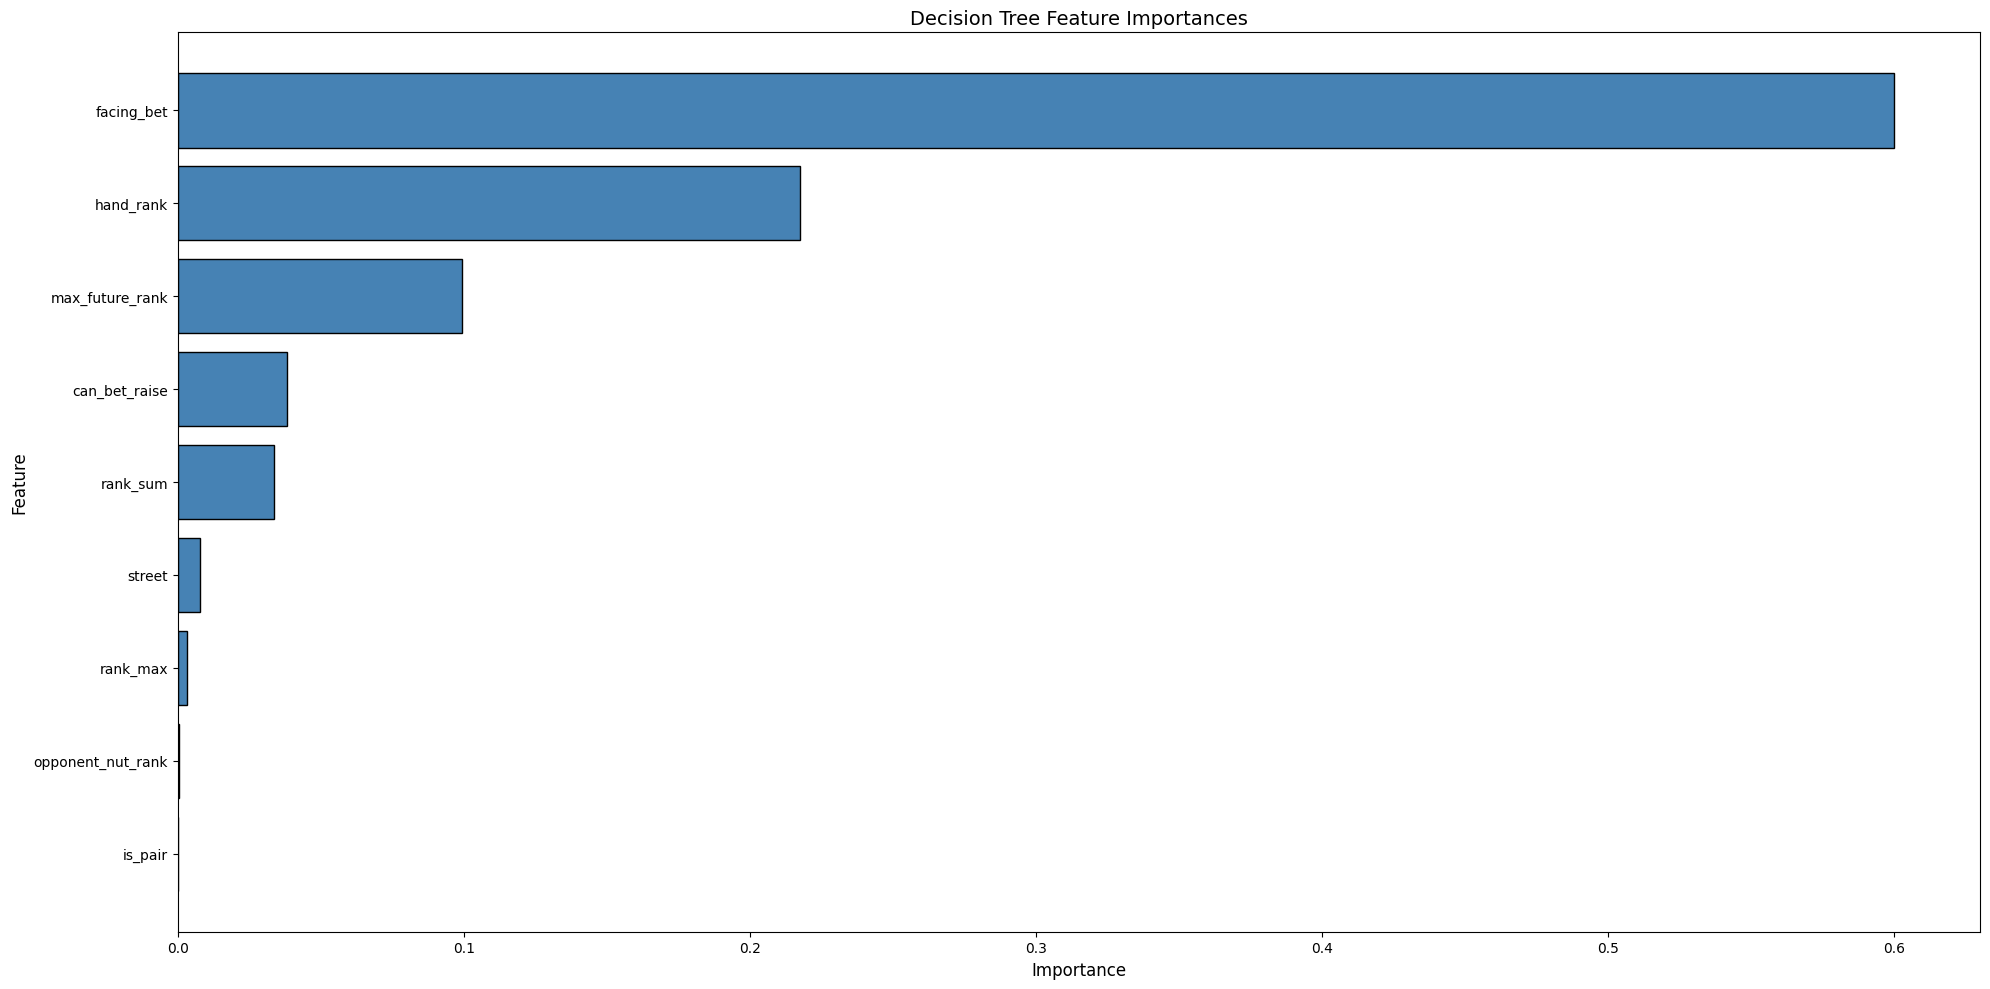

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Sort features by importance
indices = np.argsort(clf.feature_importances_)[::-1]
sorted_features = [feature_cols[i] for i in indices]
sorted_importances = clf.feature_importances_[indices]

plt.figure(figsize=(20, 10))
plt.barh(sorted_features[::-1], sorted_importances[::-1], color='steelblue', edgecolor='black')
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Decision Tree Feature Importances', fontsize=14)
plt.tight_layout()
plt.show()

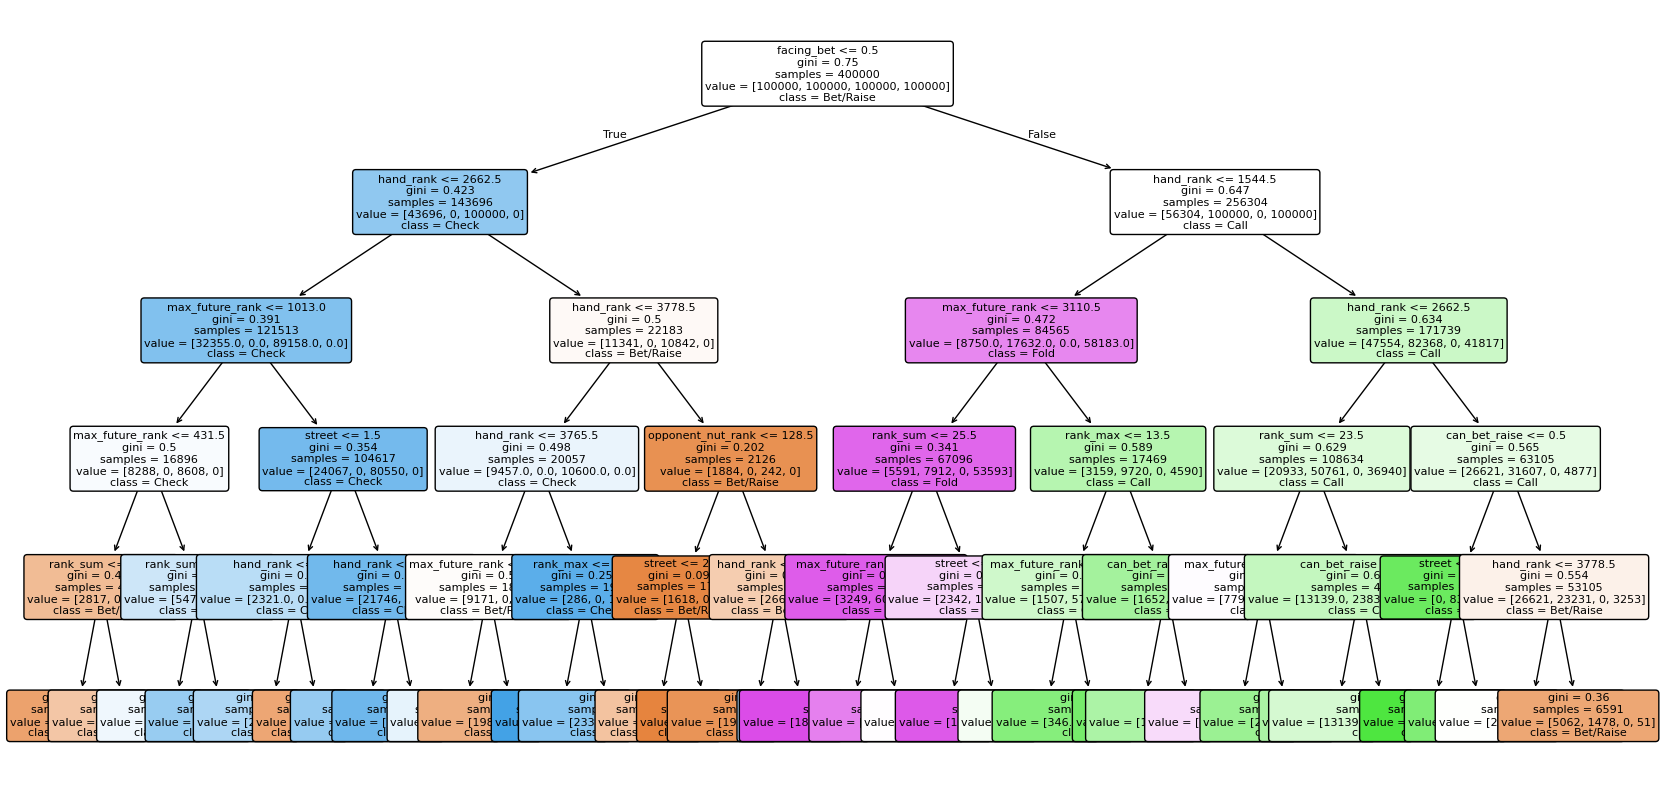

In [ ]:
# Visualize the tree
plt.figure(figsize=(20, 10))
plot_tree(
    clf,
    feature_names=X.columns,
    class_names=clf.classes_,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.show()

Intermediate Players (Basic Context)

In [ ]:
POSITION_VALUES = {'IP': 1, 'OOP': 0}

df_context = df_nut_strength_final.copy()
df_context['pot_size'] = df['pot_size']
df_context['hero_position'] = df['hero_position'].map(POSITION_VALUES)
df_context['aggressor_position'] = df['aggressor_position'].map(POSITION_VALUES)

df_context.head()

,decision_category,is_pair,rank_sum,rank_max,can_bet_raise,facing_bet,hand_rank,street,max_future_rank,opponent_nut_rank,pot_size,hero_position,aggressor_position
0,Check,0,27,14,1,0,2526,3,2526,125,21,1,0
1,Call,0,19,10,1,1,2906,2,2907,135,27,0,0
2,Call,1,24,12,0,1,2391,2,3837,125,151,1,1
3,Check,0,21,11,1,0,2248,3,2248,117,17,1,0
4,Bet/Raise,0,19,14,1,0,711,3,711,12,39,1,0


In [ ]:
# Define features and target
feature_cols = ['is_pair', 'rank_sum', 'rank_max',
                'can_bet_raise', 'facing_bet',
                'hand_rank', 'max_future_rank', 'street', 'opponent_nut_rank', 'pot_size', 'hero_position', 'aggressor_position']
X = df_context[feature_cols]
y = df_context['decision_category']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train
clf = DecisionTreeClassifier(max_depth=5, random_state=42)
clf.fit(X_train, y_train)

# Evaluate
train_acc = accuracy_score(y_train, clf.predict(X_train))
test_acc = accuracy_score(y_test, clf.predict(X_test))

print(f"Training accuracy: {train_acc:.4f} ({train_acc*100:.2f}%)")
print(f"Test accuracy:     {test_acc:.4f} ({test_acc*100:.2f}%)")

Training accuracy: 0.6766 (67.66%)
Test accuracy:     0.6772 (67.72%)


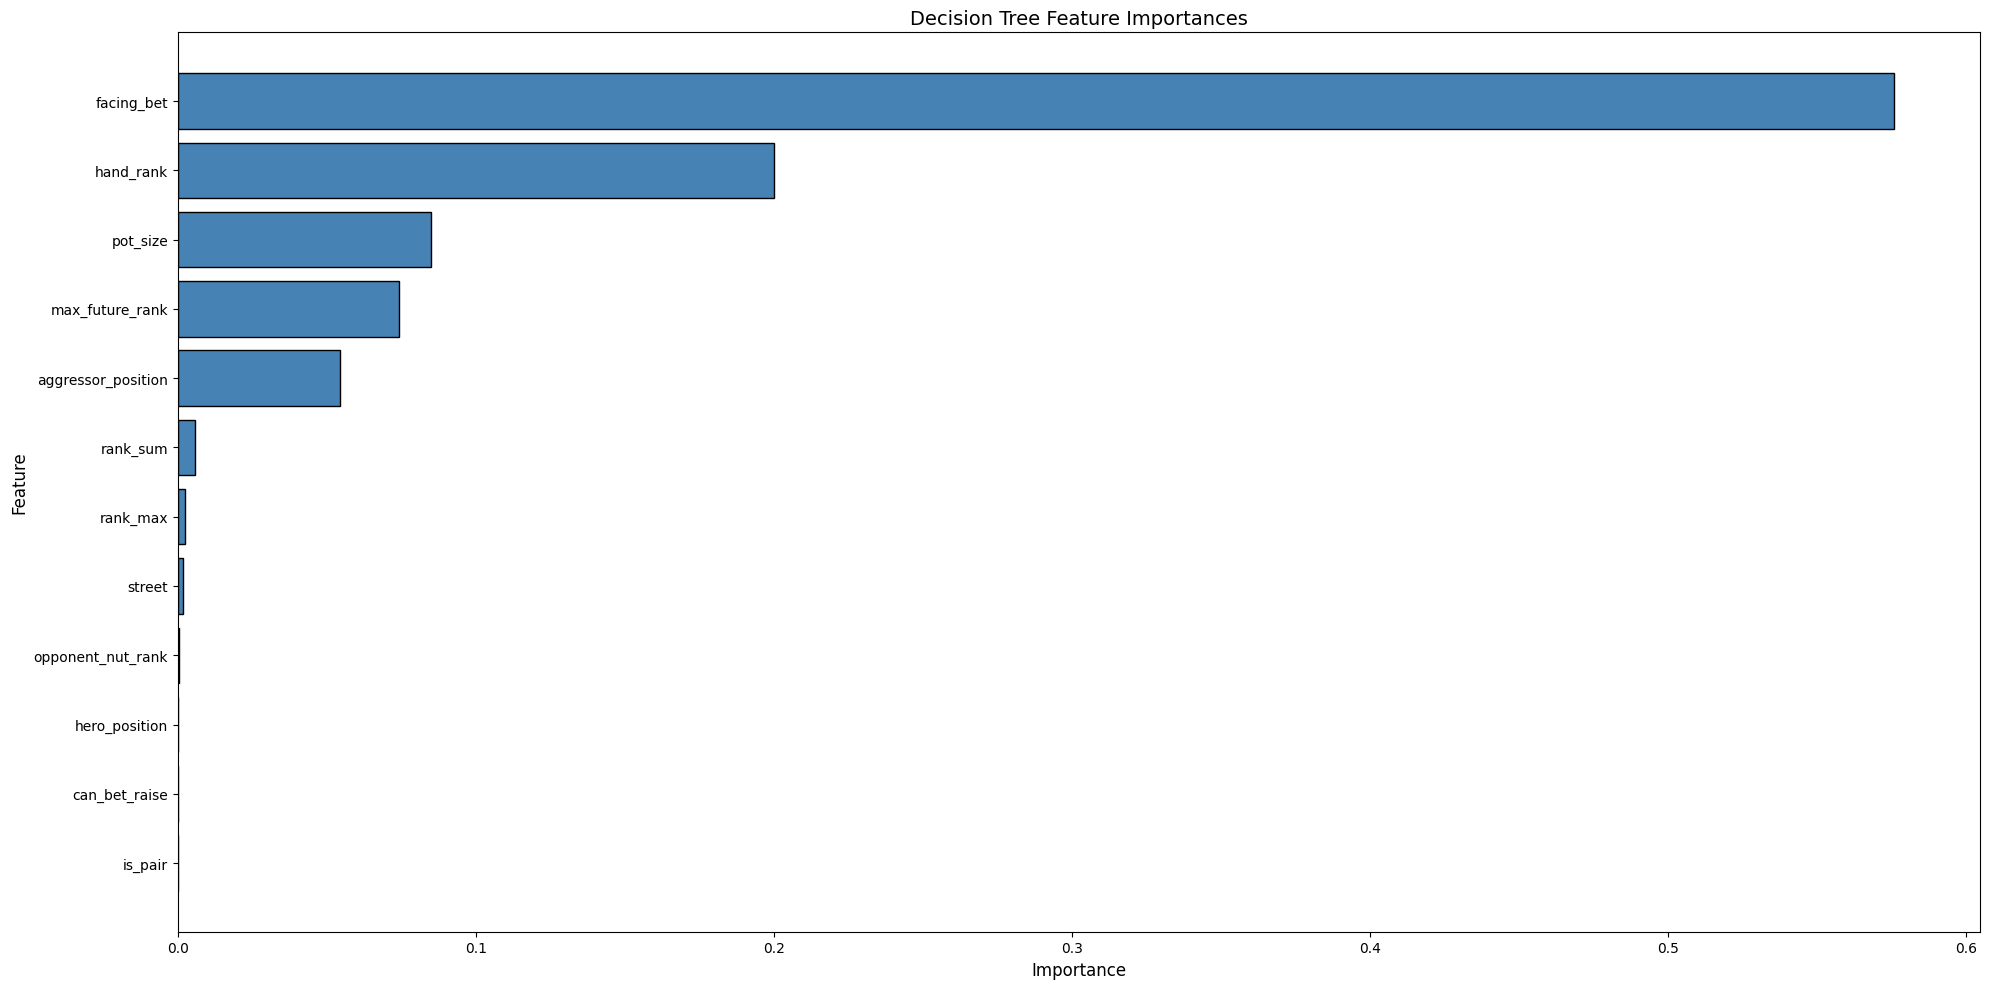

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Sort features by importance
indices = np.argsort(clf.feature_importances_)[::-1]
sorted_features = [feature_cols[i] for i in indices]
sorted_importances = clf.feature_importances_[indices]

plt.figure(figsize=(20, 10))
plt.barh(sorted_features[::-1], sorted_importances[::-1], color='steelblue', edgecolor='black')
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Decision Tree Feature Importances', fontsize=14)
plt.tight_layout()
plt.show()

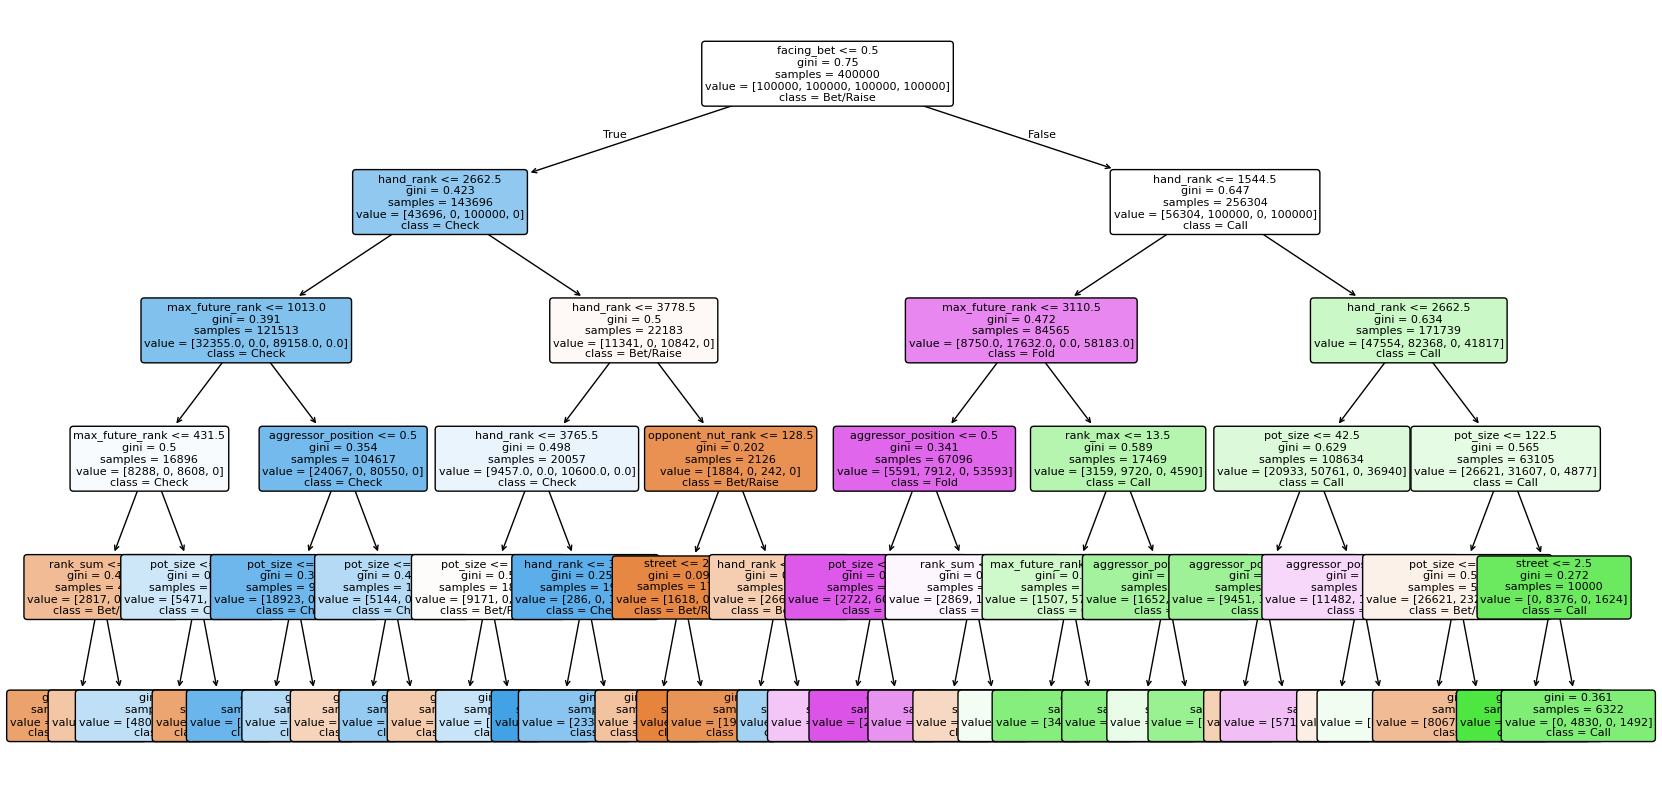

In [ ]:
# Visualize the tree
plt.figure(figsize=(20, 10))
plot_tree(
    clf,
    feature_names=X.columns,
    class_names=clf.classes_,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.show()

Intermediate Players (Action Sequences)

In [ ]:
import re
from tqdm import tqdm

# Pre-compile regex patterns (big speedup)
PREFLOP_BB_RE = re.compile(r'^([\d.]+)bb$')
POSTFLOP_BETRAISE_RE = re.compile(r'^(?:OOP|IP)_(?:BET|RAISE)_([\d.]+)$')
DEALCARDS_RE = re.compile(r'dealcards/[2-9TJQKA][hdcs]/')

# ---------- PREFLOP FEATURES ----------
def parse_preflop(action_str):
    if not isinstance(action_str, str) or action_str == '':
        return {'num_raises': 0, 'num_players': 0, 'last_raise_bb': 0.0}

    tokens = action_str.split('/')
    actions = tokens[1::2]

    raise_sizes = []
    for a in actions:
        m = PREFLOP_BB_RE.match(a)
        if m:
            raise_sizes.append(float(m.group(1)))

    positions = set(tokens[0::2])

    return {
        'num_raises': len(raise_sizes),
        'num_players': len(positions),
        'last_raise_bb': raise_sizes[-1] if raise_sizes else 0.0,
    }

# ---------- POSTFLOP FEATURES ----------
def parse_postflop(action_str):
    if not isinstance(action_str, str) or action_str == '':
        return {'current_bets_raises': 0, 'last_bet_size': 0.0}

    segments = DEALCARDS_RE.split(action_str)
    current_street = segments[-1]
    tokens = current_street.split('/') if current_street else []

    bet_raise_sizes = []
    for t in tokens:
        m = POSTFLOP_BETRAISE_RE.match(t)
        if m:
            bet_raise_sizes.append(float(m.group(1)))

    return {
        'current_bets_raises': len(bet_raise_sizes),
        'last_bet_size': bet_raise_sizes[-1] if bet_raise_sizes else 0.0,
    }

# ---------- BUILD df_action ----------
df_action = df_context.copy()

# Use a list comprehension with tqdm, then build the DataFrame in one shot
preflop_records = [
    parse_preflop(s) for s in tqdm(df['preflop_action'], desc="Parsing preflop")
]
preflop_feats = pd.DataFrame.from_records(preflop_records, index=df.index)

postflop_records = [
    parse_postflop(s) for s in tqdm(df['postflop_action'], desc="Parsing postflop")
]
postflop_feats = pd.DataFrame.from_records(postflop_records, index=df.index)

df_action['pre_num_raises'] = preflop_feats['num_raises']
df_action['pre_num_players'] = preflop_feats['num_players']
df_action['pre_last_raise_bb'] = preflop_feats['last_raise_bb']

df_action['post_bets_raises'] = postflop_feats['current_bets_raises']
df_action['post_last_bet_pct_pot'] = (
    postflop_feats['last_bet_size'] / df_action['pot_size']
).fillna(0).replace([float('inf'), -float('inf')], 0)

df_action.head()

Parsing postflop: 100%|██████████| 500000/500000 [00:00<00:00, 512311.31it/s]


,decision_category,is_pair,rank_sum,rank_max,can_bet_raise,facing_bet,hand_rank,street,max_future_rank,opponent_nut_rank,pot_size,hero_position,aggressor_position,pre_num_raises,pre_num_players,pre_last_raise_bb,post_bets_raises,post_last_bet_pct_pot
0,Check,0,27,14,1,0,2526,3,2526,125,21,1,0,1,2,2.0,0,0.000000
1,Call,0,19,10,1,1,2906,2,2907,135,27,0,0,1,2,3.0,2,0.592593
2,Call,1,24,12,0,1,2391,2,3837,125,151,1,1,2,2,6.5,2,0.509934
3,Check,0,21,11,1,0,2248,3,2248,117,17,1,0,1,2,2.0,0,0.000000
4,Bet/Raise,0,19,14,1,0,711,3,711,12,39,1,0,1,2,2.3,0,0.000000


In [ ]:
# Define features and target
feature_cols = ['is_pair', 'rank_sum', 'rank_max',
                'can_bet_raise', 'facing_bet',
                'hand_rank', 'max_future_rank', 'street',
                'opponent_nut_rank',
                'pot_size', 'hero_position', 'aggressor_position',
                'pre_num_raises', 'pre_num_players', 'pre_last_raise_bb',
                'post_bets_raises', 'post_last_bet_pct_pot']
X = df_action[feature_cols]
y = df_action['decision_category']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train
clf = DecisionTreeClassifier(max_depth=5, random_state=42)
clf.fit(X_train, y_train)

# Evaluate
train_acc = accuracy_score(y_train, clf.predict(X_train))
test_acc = accuracy_score(y_test, clf.predict(X_test))

print(f"Training accuracy: {train_acc:.4f} ({train_acc*100:.2f}%)")
print(f"Test accuracy:     {test_acc:.4f} ({test_acc*100:.2f}%)")

Training accuracy: 0.6805 (68.05%)
Test accuracy:     0.6813 (68.13%)


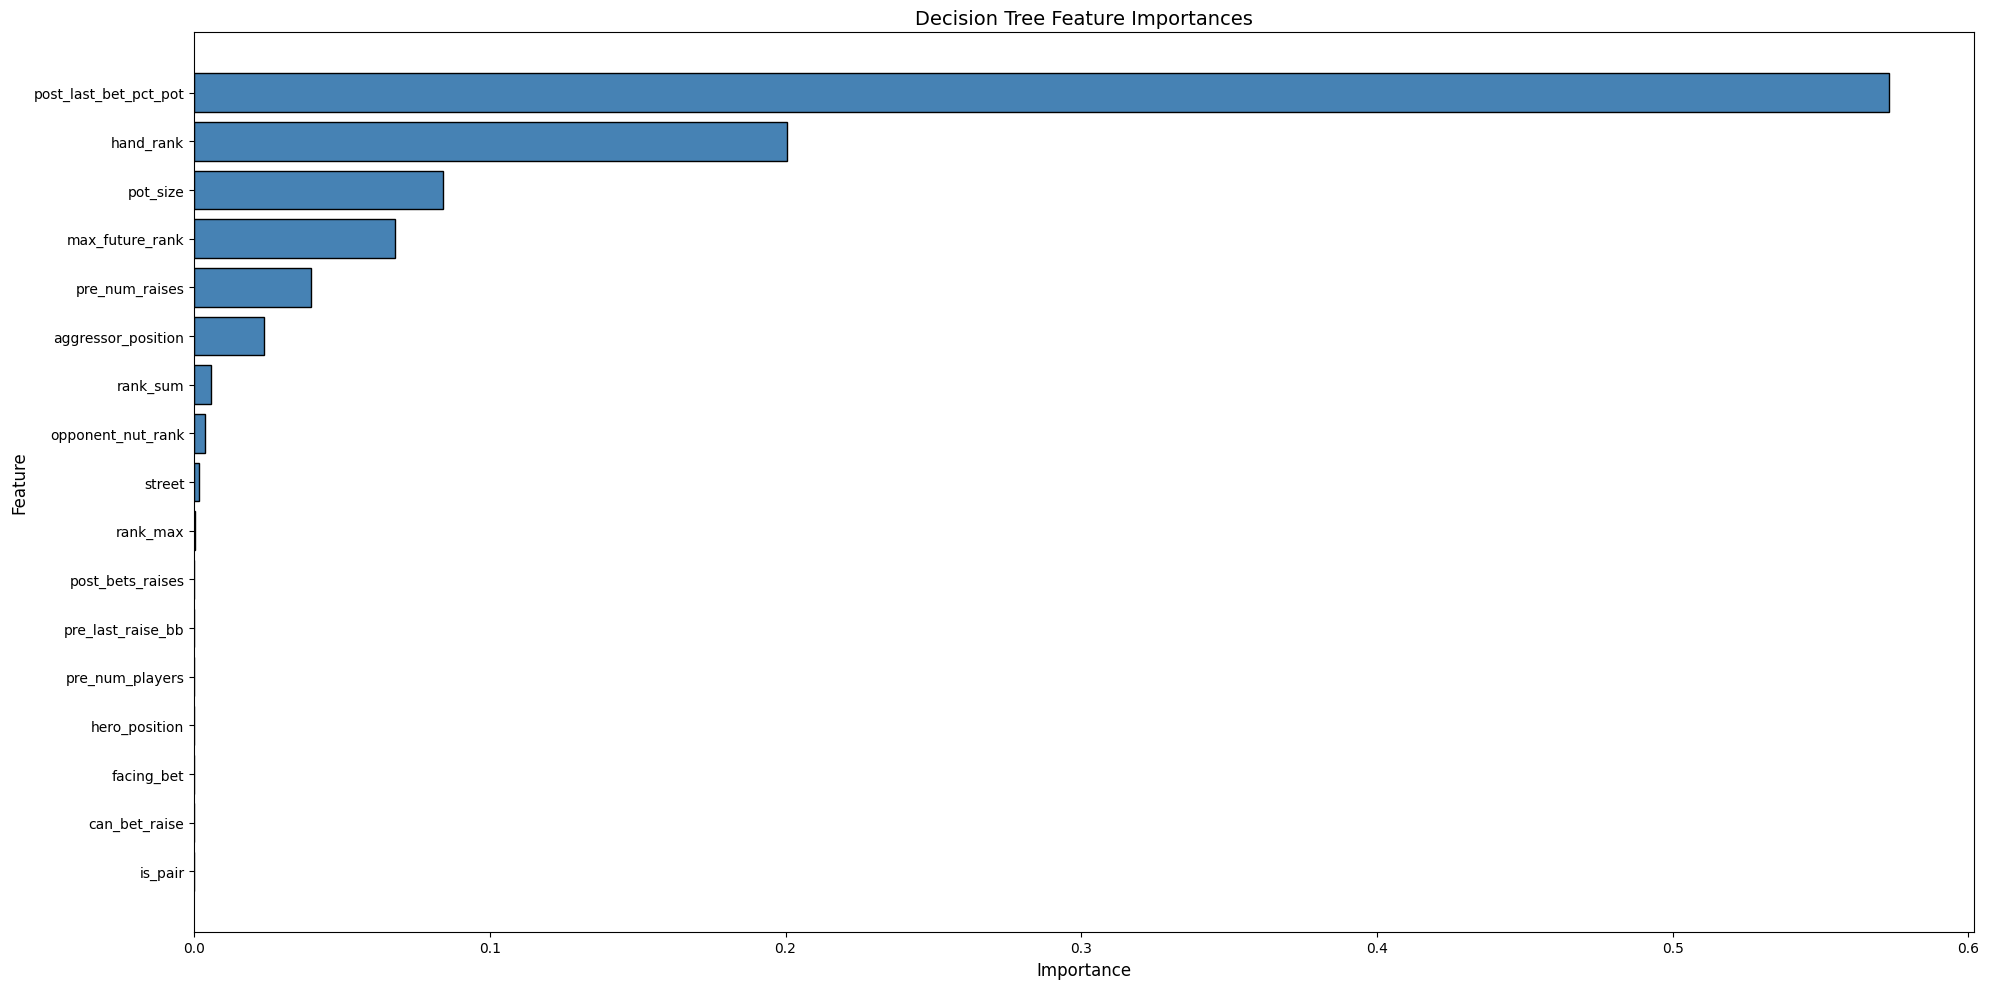

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Sort features by importance
indices = np.argsort(clf.feature_importances_)[::-1]
sorted_features = [feature_cols[i] for i in indices]
sorted_importances = clf.feature_importances_[indices]

plt.figure(figsize=(20, 10))
plt.barh(sorted_features[::-1], sorted_importances[::-1], color='steelblue', edgecolor='black')
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Decision Tree Feature Importances', fontsize=14)
plt.tight_layout()
plt.show()

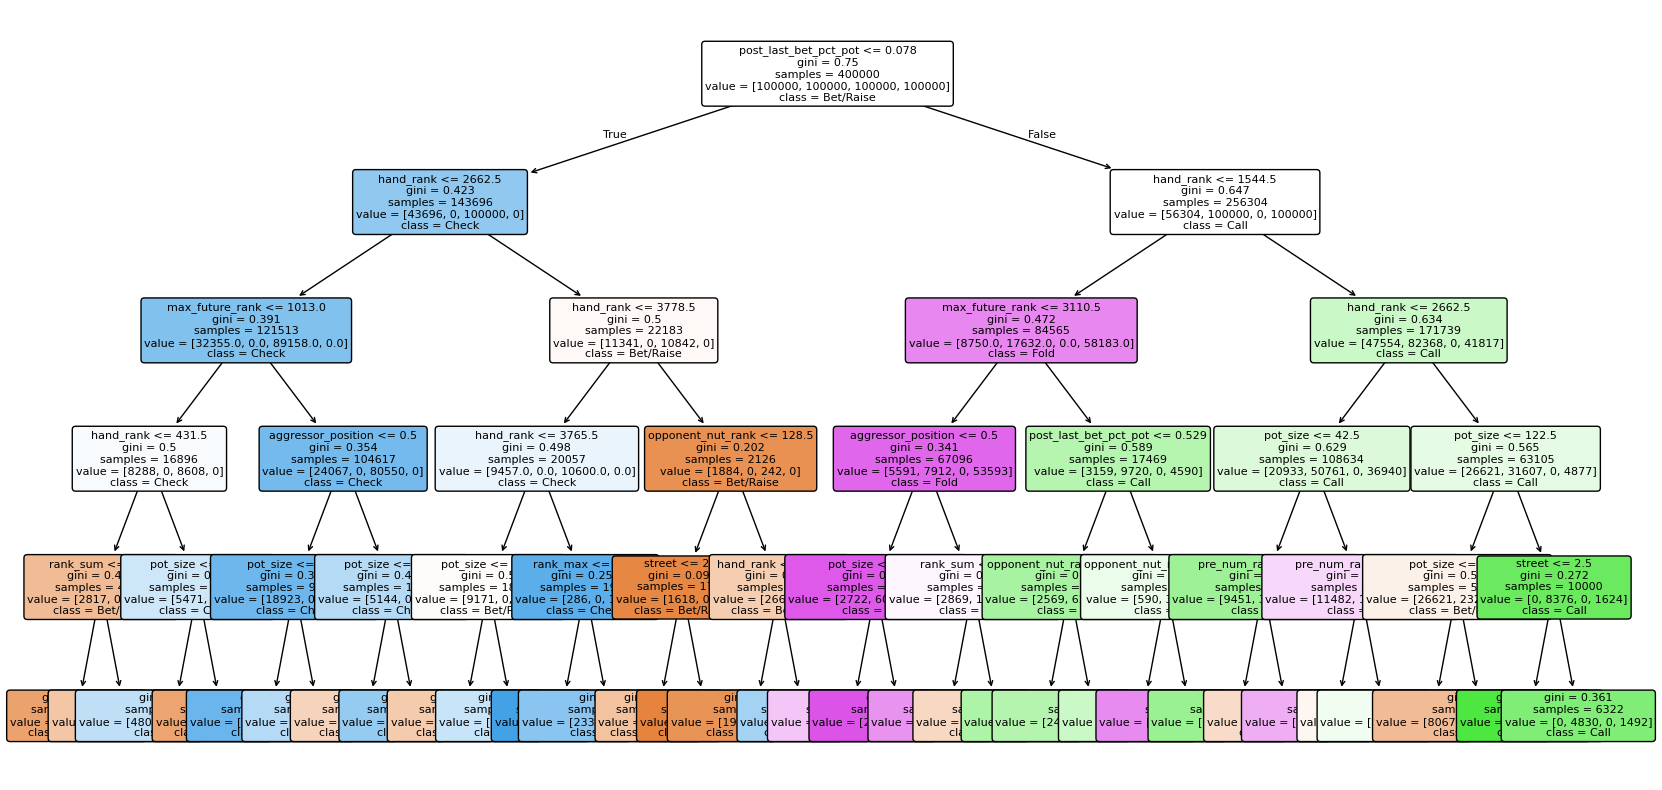

In [ ]:
# Visualize the tree
plt.figure(figsize=(20, 10))
plot_tree(
    clf,
    feature_names=X.columns,
    class_names=clf.classes_,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.show()

Exploring Depth

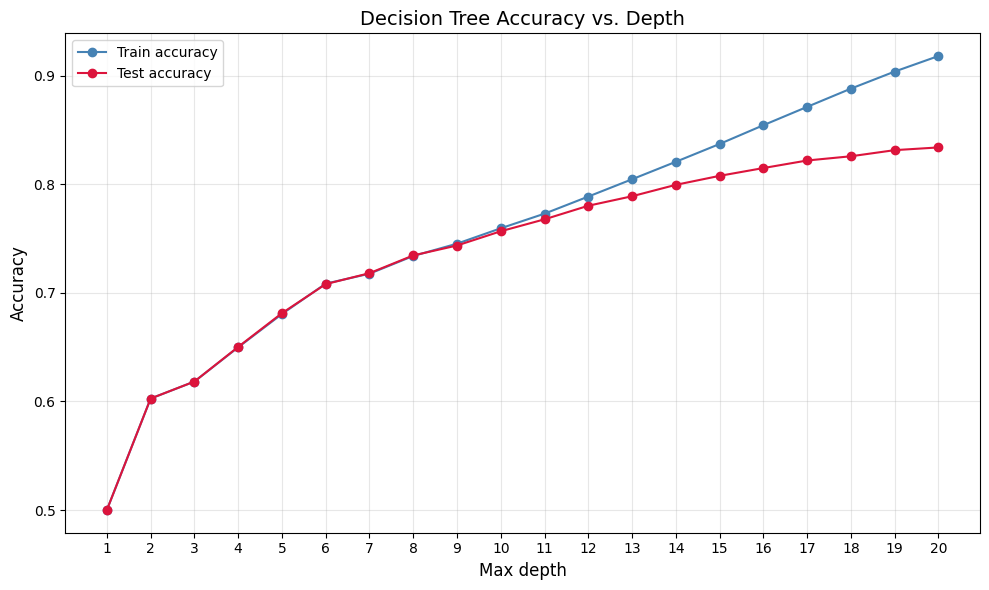

Best test accuracy: 0.8339 at depth 20


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Define features and target
feature_cols = [c for c in df_action.columns if c != 'decision_category']
X = df_action[feature_cols]
y = df_action['decision_category']

# Train/test split (once — we'll reuse for all depths)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train a tree at each depth and record accuracies
depths = list(range(1, 21))
train_accs, test_accs = [], []

for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, clf.predict(X_train)))
    test_accs.append(accuracy_score(y_test, clf.predict(X_test)))

# Plot
plt.figure(figsize=(10, 6))
plt.plot(depths, train_accs, marker='o', label='Train accuracy', color='steelblue')
plt.plot(depths, test_accs, marker='o', label='Test accuracy', color='crimson')
plt.xlabel('Max depth', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Decision Tree Accuracy vs. Depth', fontsize=14)
plt.xticks(depths)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Print the best test-accuracy depth
best_idx = int(np.argmax(test_accs))
print(f"Best test accuracy: {test_accs[best_idx]:.4f} at depth {depths[best_idx]}")

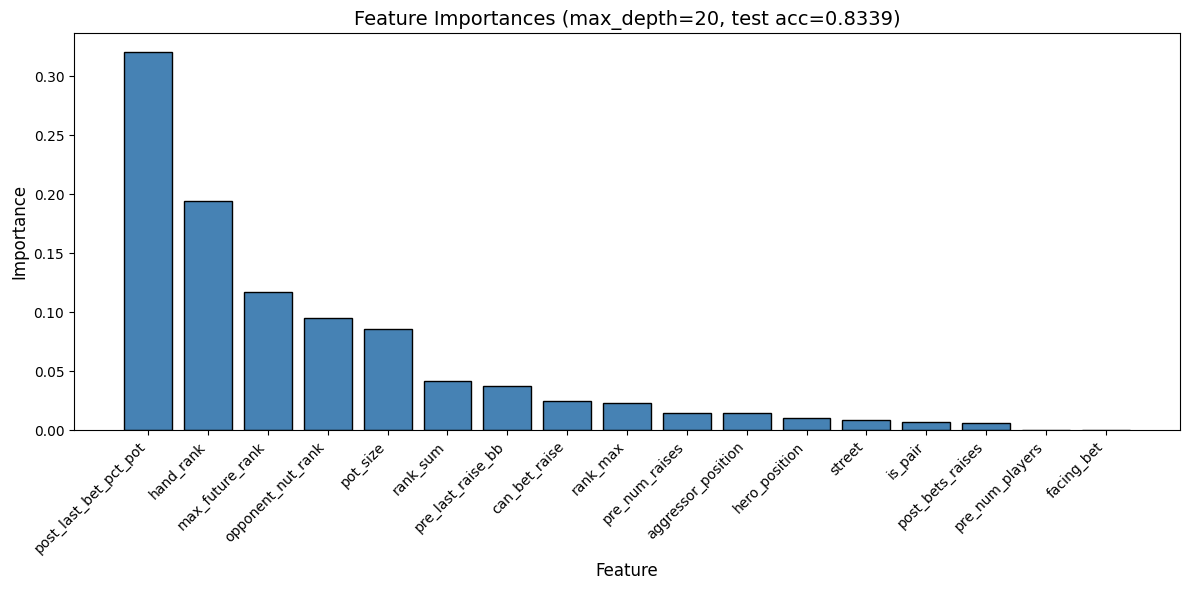


Feature importances at depth 20:
  post_last_bet_pct_pot          0.3205
  hand_rank                      0.1944
  max_future_rank                0.1167
  opponent_nut_rank              0.0954
  pot_size                       0.0860
  rank_sum                       0.0416
  pre_last_raise_bb              0.0378
  can_bet_raise                  0.0247
  rank_max                       0.0227
  pre_num_raises                 0.0148
  aggressor_position             0.0144
  hero_position                  0.0098
  street                         0.0083
  is_pair                        0.0066
  post_bets_raises               0.0063
  pre_num_players                0.0000
  facing_bet                     0.0000


In [ ]:
# Retrain at the depth that gave the best test accuracy
best_depth = depths[best_idx]
best_clf = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
best_clf.fit(X_train, y_train)

# Sort features by importance
indices = np.argsort(best_clf.feature_importances_)[::-1]
sorted_features = [feature_cols[i] for i in indices]
sorted_importances = best_clf.feature_importances_[indices]

# Plot
plt.figure(figsize=(12, 6))
plt.bar(sorted_features, sorted_importances, color='steelblue', edgecolor='black')
plt.xlabel('Feature', fontsize=12)
plt.ylabel('Importance', fontsize=12)
plt.title(f'Feature Importances (max_depth={best_depth}, test acc={test_accs[best_idx]:.4f})',
          fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.tight_layout()
plt.show()

# Also print the numbers
print(f"\nFeature importances at depth {best_depth}:")
for feat, imp in zip(sorted_features, sorted_importances):
    print(f"  {feat:30s} {imp:.4f}")

XGBoost

[0]	validation_0-mlogloss:1.29472	validation_1-mlogloss:1.29454
[50]	validation_0-mlogloss:0.55814	validation_1-mlogloss:0.55927
[100]	validation_0-mlogloss:0.50265	validation_1-mlogloss:0.50571
[150]	validation_0-mlogloss:0.47174	validation_1-mlogloss:0.47686
[200]	validation_0-mlogloss:0.44557	validation_1-mlogloss:0.45346
[250]	validation_0-mlogloss:0.42702	validation_1-mlogloss:0.43745
[300]	validation_0-mlogloss:0.41139	validation_1-mlogloss:0.42436
[350]	validation_0-mlogloss:0.39840	validation_1-mlogloss:0.41375
[400]	validation_0-mlogloss:0.38696	validation_1-mlogloss:0.40459
[450]	validation_0-mlogloss:0.37815	validation_1-mlogloss:0.39771
[499]	validation_0-mlogloss:0.37012	validation_1-mlogloss:0.39166

Training accuracy: 0.8515
Test accuracy:     0.8397


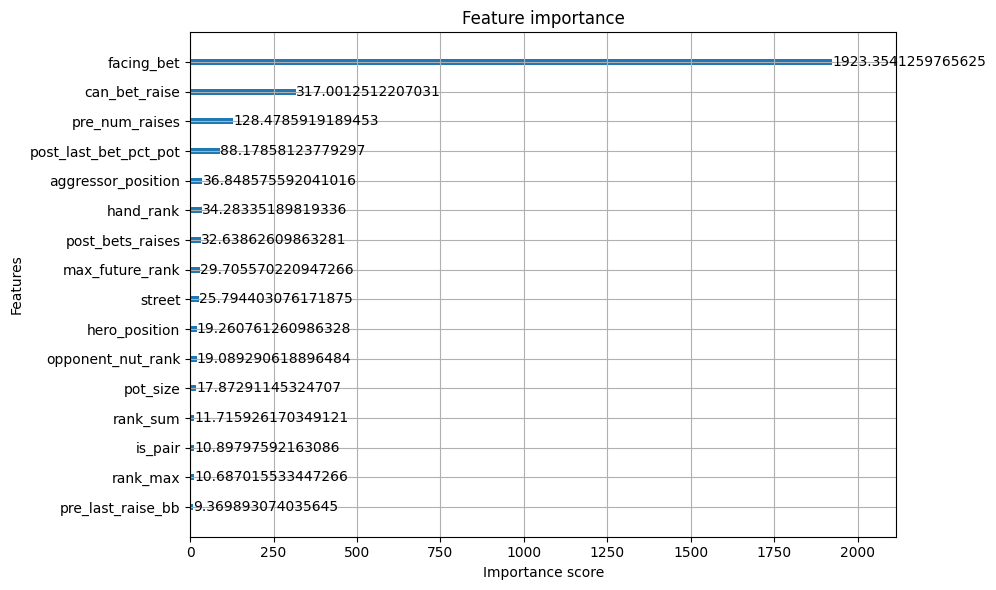

In [ ]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

# Features and target
feature_cols = [c for c in df_action.columns if c != 'decision_category']
X = df_action[feature_cols]
y = df_action['decision_category']

# XGBoost needs integer-encoded labels for multi-class
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Train
clf = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.1,
    objective='multi:softprob',
    eval_metric='mlogloss',
    early_stopping_rounds=20,
    random_state=42,
    n_jobs=-1,
    tree_method='hist',   # much faster than 'exact' on large data
)

clf.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=50,   # print progress every 50 rounds
)

# Evaluate
train_acc = accuracy_score(y_train, clf.predict(X_train))
test_acc = accuracy_score(y_test, clf.predict(X_test))

print(f"\nTraining accuracy: {train_acc:.4f}")
print(f"Test accuracy:     {test_acc:.4f}")

# Feature importance (XGBoost has its own plot helper)
fig, ax = plt.subplots(figsize=(10, 6))
xgb.plot_importance(clf, ax=ax, importance_type='gain', max_num_features=20)
plt.tight_layout()
plt.show()

XGBoost (Natural Features)

In [ ]:
import re
import numpy as np
import pandas as pd
from collections import Counter
from tqdm import tqdm

# ---------- HELPERS ----------

def card_to_idx(card):
    """'As' -> 0..51. Returns -1 if card is invalid/missing."""
    if not isinstance(card, str) or len(card) != 2:
        return -1
    try:
        return (RANK_VALUES[card[0]] - 2) * 4 + 'hdcs'.index(card[1])
    except (KeyError, ValueError):
        return -1

def cards_from_string(s):
    """'JcJh4s' -> ['Jc', 'Jh', '4s']; handles empty/NaN."""
    if not isinstance(s, str) or s == '':
        return []
    return [s[i:i+2] for i in range(0, len(s), 2)]

# ---------- CARD ONE-HOTS ----------

def build_card_onehots(df_src):
    """One-hot encode every card slot. Missing cards -> all zeros."""
    feats = {}
    slot_lookup = {
        'holding': df_src['holding'].apply(cards_from_string).values,
        'board_flop': df_src['board_flop'].apply(cards_from_string).values,
        'board_turn': df_src['board_turn'].apply(cards_from_string).values,
        'board_river': df_src['board_river'].apply(cards_from_string).values,
    }

    slots = [
        ('holding', 0, 'hole0'),
        ('holding', 1, 'hole1'),
        ('board_flop', 0, 'flop0'),
        ('board_flop', 1, 'flop1'),
        ('board_flop', 2, 'flop2'),
        ('board_turn', 0, 'turn'),
        ('board_river', 0, 'river'),
    ]

    for col, idx, prefix in slots:
        cards = slot_lookup[col]
        indices = np.array([
            card_to_idx(cards_for_row[idx]) if len(cards_for_row) > idx else -1
            for cards_for_row in cards
        ])
        onehot = np.zeros((len(df_src), 52), dtype=np.int8)
        mask = indices >= 0
        onehot[np.where(mask)[0], indices[mask]] = 1
        for c in range(52):
            feats[f'{prefix}_c{c}'] = onehot[:, c]
    return pd.DataFrame(feats, index=df_src.index)

# ---------- BOARD AGGREGATES ----------

def board_aggregate_features(df_src):
    """Suit counts, rank-duplication counts, connectedness."""
    recs = []
    for _, row in tqdm(df_src.iterrows(), total=len(df_src), desc="Board aggregates"):
        all_cards = cards_from_string(row['holding'])
        all_cards += cards_from_string(row['board_flop'])
        if row['evaluation_at'] in ('Turn', 'River'):
            all_cards += cards_from_string(row['board_turn'])
        if row['evaluation_at'] == 'River':
            all_cards += cards_from_string(row['board_river'])

        ranks = [RANK_VALUES[c[0]] for c in all_cards]
        suits = [c[1] for c in all_cards]
        suit_counts = Counter(suits)
        rank_counts = Counter(ranks)

        max_suit = max(suit_counts.values()) if suit_counts else 0
        count_dist = sorted(rank_counts.values(), reverse=True)
        n_pairs = sum(1 for c in count_dist if c == 2)
        n_trips = sum(1 for c in count_dist if c == 3)
        n_quads = sum(1 for c in count_dist if c == 4)
        rank_range = max(ranks) - min(ranks) if ranks else 0
        unique_ranks = len(set(ranks))

        rank_set = set(ranks)
        max_straight_run = 0
        for lo in range(2, 11):
            window = set(range(lo, lo + 5))
            max_straight_run = max(max_straight_run, len(window & rank_set))
        wheel = {14, 2, 3, 4, 5}
        max_straight_run = max(max_straight_run, len(wheel & rank_set))

        recs.append({
            'max_suit_count': max_suit,
            'n_pairs': n_pairs,
            'n_trips': n_trips,
            'n_quads': n_quads,
            'rank_range': rank_range,
            'n_unique_ranks': unique_ranks,
            'max_straight_run': max_straight_run,
        })
    return pd.DataFrame.from_records(recs, index=df_src.index)

# ---------- ACTION SEQUENCE FEATURES ----------

POSTFLOP_TOKEN_RE = re.compile(r'^(OOP|IP)_(CHECK|CALL|BET|RAISE|FOLD)(?:_([\d.]+))?$')

def action_sequence_features(action_str):
    """Per-street action counts and sizing stats from the postflop_action string."""
    if not isinstance(action_str, str) or action_str == '':
        return {}

    parts = re.split(r'dealcards/[2-9TJQKA][hdcs]/', action_str)
    street_names = ['flop', 'turn', 'river']

    feats = {}
    for i, seg in enumerate(parts):
        name = street_names[i] if i < 3 else f'extra{i}'
        tokens = seg.split('/') if seg else []

        n_bet = n_raise = n_check = n_call = 0
        sizes = []
        for t in tokens:
            m = POSTFLOP_TOKEN_RE.match(t)
            if not m:
                continue
            action = m.group(2)
            size = m.group(3)
            if action == 'BET':
                n_bet += 1
                if size: sizes.append(float(size))
            elif action == 'RAISE':
                n_raise += 1
                if size: sizes.append(float(size))
            elif action == 'CHECK':
                n_check += 1
            elif action == 'CALL':
                n_call += 1

        feats[f'{name}_n_bet'] = n_bet
        feats[f'{name}_n_raise'] = n_raise
        feats[f'{name}_n_check'] = n_check
        feats[f'{name}_n_call'] = n_call
        feats[f'{name}_max_size'] = max(sizes) if sizes else 0.0
        feats[f'{name}_sum_size'] = sum(sizes)
    return feats

# ---------- ASSEMBLE df_rich ----------

print("Building card one-hots...")
card_feats = build_card_onehots(df_simplified)

print("Building board aggregates...")
board_feats = board_aggregate_features(df_simplified)

print("Parsing action sequences...")
action_records = [
    action_sequence_features(s)
    for s in tqdm(df['postflop_action'], desc="Actions")
]
action_feats = pd.DataFrame.from_records(action_records, index=df.index).fillna(0)

df_rich = pd.concat([df_action, card_feats, board_feats, action_feats], axis=1)
df_rich = df_rich.loc[:, ~df_rich.columns.duplicated()]

print(f"Feature count: {df_rich.shape[1] - 1} (was {df_action.shape[1] - 1})")
print(df_rich.head())

Building card one-hots...
Building board aggregates...


Board aggregates: 100%|██████████| 500000/500000 [00:31<00:00, 15893.41it/s]


Parsing action sequences...


Actions: 100%|██████████| 500000/500000 [00:04<00:00, 117893.87it/s]


Feature count: 406 (was 17)
  decision_category  is_pair  rank_sum  rank_max  can_bet_raise  facing_bet  \
0             Check        0        27        14              1           0   
1              Call        0        19        10              1           1   
2              Call        1        24        12              0           1   
3             Check        0        21        11              1           0   
4         Bet/Raise        0        19        14              1           0   

   hand_rank  street  max_future_rank  opponent_nut_rank  ...  turn_n_check  \
0       2526       3             2526                125  ...           1.0   
1       2906       2             2907                135  ...           0.0   
2       2391       2             3837                125  ...           1.0   
3       2248       3             2248                117  ...           0.0   
4        711       3              711                 12  ...           1.0   

   turn_n_call  turn_m

In [ ]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

feature_cols = [c for c in df_rich.columns if c != 'decision_category']
X = df_rich[feature_cols]
y = df_rich['decision_category']

le = LabelEncoder()
y_enc = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

clf = xgb.XGBClassifier(
    n_estimators=1000,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softprob',
    eval_metric='mlogloss',
    early_stopping_rounds=30,
    random_state=42,
    n_jobs=-1,
    tree_method='hist',
)

clf.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=100)

print(f"Test accuracy: {accuracy_score(y_test, clf.predict(X_test)):.4f}")

[0]	validation_0-mlogloss:1.33485
[100]	validation_0-mlogloss:0.46464
[200]	validation_0-mlogloss:0.39309
[300]	validation_0-mlogloss:0.36049
[400]	validation_0-mlogloss:0.33957
[500]	validation_0-mlogloss:0.32310
[600]	validation_0-mlogloss:0.31059
[700]	validation_0-mlogloss:0.30059
[800]	validation_0-mlogloss:0.29237
[900]	validation_0-mlogloss:0.28537
[999]	validation_0-mlogloss:0.27950
Test accuracy: 0.8936
